# 1. Business Problem

# Business Problem Statement

## Background

LendingClub is a US-based peer-to-peer (P2P) lending platform that connects borrowers with investors. Unlike traditional banks, LendingClub facilitates loans by matching borrower applications with investor funding. The platform has issued hundreds of thousands of loans since its inception in 2007.

In a lending business, the primary risk is **credit risk** — the risk that a borrower fails to repay their loan (default). Each approved loan that ends in default results in a direct financial loss equal to the unpaid principal amount. Conversely, rejecting a creditworthy borrower results in an opportunity loss (foregone interest income).

## The Business Problem

**How can LendingClub accurately predict which loan applicants are likely to default, enabling the platform to make data-driven approval decisions that maximize net financial return?**

More specifically, this project aims to:

1. **Identify high-risk applicants** early in the application process
2. **Reduce default rates** by rejecting applicants with high probability of non-payment
3. **Minimize opportunity loss** by approving creditworthy applicants
4. **Optimize the trade-off** between catching bad loans (True Positives) and wrongly rejecting good loans (False Positives)

## Business Impact

### Current State (Without Model)
Without a predictive model, LendingClub would rely on:
- Manual underwriting (slow, inconsistent, expensive)
- Simple rule-based filtering (e.g., minimum credit score)
- Intuition-based decisions

**Result:** Higher default rates, inconsistent decisions, and suboptimal portfolio performance.

### Desired State (With Model)
With an accurate predictive model, LendingClub can:
- **Automate approval decisions** for standard applications
- **Reduce default rates** by identifying risky applicants early
- **Increase approval rates** for creditworthy borrowers who might be rejected by traditional rules
- **Optimize pricing** (interest rates) based on predicted risk
- **Scale operations** without proportional increase in underwriting staff

## Success Criteria

### Primary Metric
**Net Business Impact** — The total financial outcome combining:
- **Profit from correct approvals** (True Negatives): Good loans that perform as expected
- **Savings from correct rejections** (True Positives): Bad loans prevented
- **Loss from incorrect approvals** (False Negatives): Bad loans that default
- **Opportunity loss from incorrect rejections** (False Positives): Good loans rejected

### Secondary Metrics
| Metric | Target | Rationale |
|--------|--------|-----------|
| ROC-AUC | > 0.70 | Model's ability to distinguish good vs bad loans |
| Recall (Bad Loans) | > 0.50 | Catching at least half of potential defaults |
| Precision (Bad Loans) | > 0.30 | Acceptable level of false positives |

### Business Constraints
1. **False Negatives (missed defaults)** are more costly than False Positives
2. Model must be **interpretable** enough to explain decisions to regulators
3. Predictions must be **fast** (< 1 second per application) for real-time use
4. Model should **generalize** across different economic conditions

## Stakeholders

| Stakeholder | Interest |
|-------------|----------|
| **LendingClub (Platform)** | Minimize defaults, maximize platform revenue |
| **Investors** | Earn positive returns on their invested capital |
| **Borrowers** | Fair and fast credit decisions |
| **Regulators** | Non-discriminatory, transparent lending practices |

## Data Availability

Historical loan data from 2007-2014 is available, containing:
- ~466,000 loan applications
- ~75 features per application
- Known outcomes

This data enables supervised learning to predict future loan performance.

## Proposed Solution

Build a machine learning model (XGBoost) that:

1. **Learns patterns** from historical loan data
2. **Predicts default probability** for new applications
3. **Applies business-optimized threshold** to make approve/reject decisions
4. **Provides feature importance** to explain predictions

## Expected ROI

Based on historical data analysis:
- **Without model:** ~19% default rate in test set
- **With optimized model:** 
  - Catch 56% of defaults (Recall)
  - Reduce effective default rate to ~11%
  - Net business impact: **$33M+** on test portfolio

## Risks & Mitigations

| Risk | Mitigation |
|------|------------|
| Model performance degrades over time | Regular retraining with new data |
| Economic conditions change | Monitor model drift; include economic indicators |
| Regulatory compliance issues | Use interpretable features; document decisions |
| Implementation complexity | Start with batch predictions; evolve to real-time API |

# 2. Libraries Import and Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import time
import joblib
import os
from datetime import datetime
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                             roc_curve, precision_recall_curve, f1_score, recall_score, precision_score)
from scipy.stats import chi2_contingency

In [2]:
df = pd.read_csv("C:\Prima\Github\Data\loan_data_2007_2014.csv")
pd.set_option('display.max_columns', None)

C:\Users\prima\AppData\Local\Temp\ipykernel_3464\537107180.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\Prima\Github\Data\loan_data_2007_2014.csv")


In [3]:
df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

### Dataset Columns Description

| Column Name | Description |
|------------|-------------|
| acc_now_delinq | Number of accounts on which the borrower is currently delinquent |
| addr_state | State provided by the borrower in the loan application |
| annual_inc | Self-reported annual income of the borrower |
| application_type | Indicates whether the loan is individual or joint application |
| collection_recovery_fee | Post charge-off collection fee |
| collections_12_mths_ex_med | Number of collections in the last 12 months excluding medical collections |
| delinq_2yrs | Number of 30+ days delinquency incidents in the past 2 years |
| desc | Loan description provided by the borrower |
| dti | Debt-to-income ratio excluding mortgage and requested loan |
| earliest_cr_line | Month when the borrower's earliest credit line was opened |
| emp_length | Employment length in years (0–10, where 10 means 10+ years) |
| emp_title | Job title provided by the borrower |
| funded_amnt | Total amount funded for the loan |
| funded_amnt_inv | Total amount funded by investors |
| grade | Loan grade assigned by Lending Club |
| home_ownership | Home ownership status (RENT, OWN, MORTGAGE, OTHER) |
| id | Unique loan listing ID |
| initial_list_status | Initial listing status of the loan (W, F) |
| inq_last_6mths | Number of credit inquiries in the past 6 months |
| installment | Monthly payment owed by the borrower |
| int_rate | Interest rate on the loan |
| issue_d | Month when the loan was issued |
| last_credit_pull_d | Most recent month credit was pulled |
| last_pymnt_amnt | Last payment amount received |
| last_pymnt_d | Month when the last payment was received |
| loan_amnt | Loan amount applied for by the borrower |
| loan_status | Current status of the loan (target variable) |
| member_id | Unique borrower ID |
| mths_since_last_delinq | Months since last delinquency |
| mths_since_last_major_derog | Months since most recent major derogatory event (90+ days late) |
| mths_since_last_record | Months since last public record |
| next_pymnt_d | Next scheduled payment date |
| open_acc | Number of open credit accounts |
| out_prncp | Remaining outstanding principal |
| out_prncp_inv | Remaining outstanding principal funded by investors |
| policy_code | Policy code (1 = publicly available, 2 = not publicly available) |
| pub_rec | Number of derogatory public records |
| purpose | Purpose of the loan |
| pymnt_plan | Indicates whether a payment plan is in place |
| recoveries | Post charge-off gross recovery |
| revol_bal | Total revolving credit balance |
| revol_util | Revolving credit utilization rate |
| sub_grade | Loan sub-grade assigned by Lending Club |
| term | Loan term in months (36 or 60) |
| title | Loan title provided by the borrower |
| tot_coll_amt | Total collection amounts ever owed |
| tot_cur_bal | Total current balance of all credit accounts |
| total_acc | Total number of credit accounts |
| total_pymnt | Total payments received to date |
| total_pymnt_inv | Total payments received by investors |
| total_rec_int | Total interest received |
| total_rec_late_fee | Total late fees received |
| total_rec_prncp | Total principal received |
| total_rev_hi_lim | Total revolving credit limit |
| url | URL of the loan listing page |
| verification_status | Income verification status |
| zip_code | First three digits of borrower’s ZIP code |

# 3. Exploratory Data Analysis, Data Cleaning, and Feature Engineering

## 3.1 Drop Unnecessary Columns

In [5]:
check_missing = df.isnull().sum() * 100 / df.shape[0]
print("Here is columns with null values and its percentage:")
print(check_missing[check_missing > 0].sort_values(ascending=False))
print("="*42)
print(f'Total there are {len(check_missing[check_missing > 0])} columns with null values')

Here is columns with null values and its percentage:
inq_fi                         100.000000
open_rv_24m                    100.000000
max_bal_bc                     100.000000
all_util                       100.000000
inq_last_12m                   100.000000
annual_inc_joint               100.000000
verification_status_joint      100.000000
dti_joint                      100.000000
total_cu_tl                    100.000000
il_util                        100.000000
mths_since_rcnt_il             100.000000
total_bal_il                   100.000000
open_il_24m                    100.000000
open_il_12m                    100.000000
open_il_6m                     100.000000
open_acc_6m                    100.000000
open_rv_12m                    100.000000
mths_since_last_record          86.566585
mths_since_last_major_derog     78.773926
desc                            72.981975
mths_since_last_delinq          53.690554
next_pymnt_d                    48.728567
tot_cur_bal            

In [6]:
df.dropna(axis = 1, how = "all", inplace = True)

In [7]:
# 1. NO PREDICTIVE VALUE (identifiers, free text, duplicates)
no_predictive_value = [
    'Unnamed: 0', 'id', 'member_id', 'url',           # Identifiers
    'desc', 'title', 'emp_title',                      # Free text
    'sub_grade',                                        # Redundant with grade
    'funded_amnt', 'funded_amnt_inv',                  # Duplicate of loan_amnt
    'out_prncp', 'out_prncp_inv',                      # Post-loan info
    'zip_code',                                         # Too granular
]

# 2. DATA LEAKAGE (information not available at application time)
data_leakage = [
    'total_pymnt', 'total_pymnt_inv',                  # Payments made
    'total_rec_prncp', 'total_rec_int',                # Received payments
    'total_rec_late_fee',                              # Late fees incurred
    'recoveries', 'collection_recovery_fee',           # Post-default recovery
    'last_pymnt_d', 'last_pymnt_amnt',                 # Last payment info
    'next_pymnt_d',                                    # Future payment date
    'last_credit_pull_d',                              # Post-loan credit pull
    'pymnt_plan',                                      # Payment plan (post-issue)
    'acc_now_delinq',                                  # Current delinquency status
]

# 3. INSUFFICIENT VARIANCE (constant or extremely imbalanced)
insufficient_variance = [
    'policy_code',                                      # Constant value
    'initial_list_status',                              # Not information of a lender
]

# 4. COMBINE ALL COLUMNS TO DROP
useless_columns = list(set(
    no_predictive_value + 
    data_leakage + 
    insufficient_variance
))

In [8]:
df.drop(columns = useless_columns, inplace = True)

## 3.2 Drop Unnecessary Rows

In [9]:
df['loan_status'].value_counts(normalize=True)*100

loan_status
Current                                                48.087757
Fully Paid                                             39.619332
Charged Off                                             9.109236
Late (31-120 days)                                      1.479782
In Grace Period                                         0.674695
Does not meet the credit policy. Status:Fully Paid      0.426349
Late (16-30 days)                                       0.261214
Default                                                 0.178432
Does not meet the credit policy. Status:Charged Off     0.163205
Name: proportion, dtype: float64

In [10]:
loan_status_mapping = {
    # GOOD
    "Fully Paid": 0,
    "Does not meet the credit policy. Status:Fully Paid": 0,

    # BAD
    "Charged Off": 1,
    "Default": 1,
    "Does not meet the credit policy. Status:Charged Off": 1,
}

In [11]:
df = df[df['loan_status'].isin(loan_status_mapping)]
df["status_bad"] = df["loan_status"].map(loan_status_mapping)
df = df.dropna(subset=["status_bad"])
df["status_bad"] = df["status_bad"].astype("Int64")
df = df.drop(columns=["loan_status"])
df["status_bad"].value_counts(normalize=True)

status_bad
0    0.80906
1    0.19094
Name: proportion, dtype: Float64

## 3.3 Fix Data Type and Clean Its Values

In [12]:
# check data type of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 230795 entries, 0 to 466283
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    230795 non-null  int64  
 1   term                         230795 non-null  object 
 2   int_rate                     230795 non-null  float64
 3   installment                  230795 non-null  float64
 4   grade                        230795 non-null  object 
 5   emp_length                   222040 non-null  object 
 6   home_ownership               230795 non-null  object 
 7   annual_inc                   230791 non-null  float64
 8   verification_status          230795 non-null  object 
 9   issue_d                      230795 non-null  object 
 10  purpose                      230795 non-null  object 
 11  addr_state                   230795 non-null  object 
 12  dti                          230795 non-null  float64
 13  deli

In [13]:
# Checking basic data information
def check_data_information(df, cols):
    """
    This function provides detailed information about each column in a dataframe, including:
    - Data type of the column
    - Number of missing (null) values
    - Percentage of missing values
    - Total number of duplicated rows in the dataframe (not column-specific)
    - Number of unique values in the column
    - A sample of up to 5 unique values from the column

    Parameters:
    df (pd.DataFrame): The dataframe you want to check.
    cols (list): List of column names to check the information from.

    Returns:
    pd.DataFrame: A dataframe with detailed information for each column.
    """
    list_item = []
    for col in cols:
        list_item.append([col,                             # The column name
                          df[col].dtype,                   # The data type of the column
                          df[col].isna().sum(),            # The count of null values in the column
                          round(100 * df[col].isna().sum() / len(df[col]), 2),  # The percentage of null values
                          df.duplicated().sum(),           # The count of duplicated rows in the entire dataframe
                          df[col].nunique(),               # The count of unique values in the column
                          str(df[col].unique()[:5])])           # A sample of the first 5 unique values in the column

    desc_df = pd.DataFrame(data=list_item, columns='Feature, Data Type, Null Values, Null Percentage, Duplicated Values, Unique Values, Unique Sample'.split(","))
    return desc_df

In [14]:
columns_to_check = df.columns
check_data_information(df, columns_to_check)

,Feature,Data Type,Null Values,Null Percentage,Duplicated Values,Unique Values,Unique Sample
0,loan_amnt,int64,0,0.00,0,1308,[ 5000 2500 2400 10000 3000]
1,term,object,0,0.00,0,2,[' 36 months' ' 60 months']
2,int_rate,float64,0,0.00,0,505,[10.65 15.27 15.96 13.49 7.9 ]
3,installment,float64,0,0.00,0,43071,[162.87 59.83 84.33 339.31 156.46]
4,grade,object,0,0.00,0,7,['B' 'C' 'A' 'E' 'F']
5,emp_length,object,8755,3.79,0,11,['10+ years' '< 1 year' '3 years' '9 years' '4...
6,home_ownership,object,0,0.00,0,6,['RENT' 'OWN' 'MORTGAGE' 'OTHER' 'NONE']
7,annual_inc,float64,4,0.00,0,18195,[24000. 30000. 12252. 49200. 36000.]
8,verification_status,object,0,0.00,0,3,['Verified' 'Source Verified' 'Not Verified']
9,issue_d,object,0,0.00,0,91,['Dec-11' 'Nov-11' 'Oct-11' 'Sep-11' 'Aug-11']


- `application_type` only consist of single value. We'll drop later along with other column (if exist) after cleaning  
- Some object-typed columns consist many unique value. We'll group them and also drop object-typed column with few unique value but imbalance.

In [15]:
obj_col = df.select_dtypes(include = 'object').columns
obj_col

Index(['term', 'grade', 'emp_length', 'home_ownership', 'verification_status',
       'issue_d', 'purpose', 'addr_state', 'earliest_cr_line',
       'application_type'],
      dtype='object')

All correct as object except `earliest_cr_line` and `issue_d`.  
Change `earliest_cr_line` and `issue_d` to date.

### 3.3.1 Handle Datetime Type

`earliest_cr_line` and `issue_d` previously having 'MM-YY' format such as 'Dec-11'. We need to change them into 'YYYY-MM-DD' format for later analysis. We'll assume the 'DD' is '01' which means first date of a month. Change them directly is problematic because the computer will translate 'Jan-65' as '2065-01-01' which is not correct (it must be '1965-01-01'). That's why we need to create function date_parse to handle this.

In [16]:
def date_parse(val):
    if pd.isna(val):
        return pd.NaT
    
    month_str, year_str = val.split("-")
    year = int(year_str)
    
    if year >= 30:
        year += 1900
    else:
        year += 2000
    
    return pd.to_datetime(f"{year}-{month_str}-01", format="%Y-%b-%d")


In [17]:
# Apply date_parse on earliest_cr_line and issue_d columns
df["earliest_cr_line"] = df["earliest_cr_line"].apply(date_parse)
df["issue_d"] = df["issue_d"].apply(date_parse)

# Check to make sure no date in which loan was issued is earlier than earliest credit line issued
(df["earliest_cr_line"] > df["issue_d"]).sum()

np.int64(0)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 230795 entries, 0 to 466283
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   loan_amnt                    230795 non-null  int64         
 1   term                         230795 non-null  object        
 2   int_rate                     230795 non-null  float64       
 3   installment                  230795 non-null  float64       
 4   grade                        230795 non-null  object        
 5   emp_length                   222040 non-null  object        
 6   home_ownership               230795 non-null  object        
 7   annual_inc                   230791 non-null  float64       
 8   verification_status          230795 non-null  object        
 9   issue_d                      230795 non-null  datetime64[ns]
 10  purpose                      230795 non-null  object        
 11  addr_state                   23

### 3.3.2 Handle Numeric Type

In [19]:
# Change data type to allow null values
int_cols = df.select_dtypes(include='int64').columns
df[int_cols] = df[int_cols].astype('Int64')

float_cols = df.select_dtypes(include='float64').columns
df[float_cols] = df[float_cols].astype('Float64')

# Convert values to decimal
df['int_rate'] = df['int_rate']/100
df['dti'] = df['dti']/100
df['revol_util'] = df['revol_util']/100
df['revol_util'] = df['revol_util'].clip(upper=1.0)

In [20]:
# Check the presence of duplicated value
df.duplicated().sum()

np.int64(0)

### 3.3.3 Handle Categorical Type

In [21]:
# Check each unique value of object-typed columns and their distribution
cat_col = df.select_dtypes(include = 'object').columns
for col in cat_col:
    print(f'Column name: ', col)
    print(df[col].unique())
    print(f"Distribution of unique value in column {col} (in percent):")
    print((df[col].value_counts(normalize = True)*100).sort_values(ascending = False))
    print("="*50)

Column name:  term
[' 36 months' ' 60 months']
Distribution of unique value in column term (in percent):
term
36 months    78.634286
60 months    21.365714
Name: proportion, dtype: float64
Column name:  grade
['B' 'C' 'A' 'E' 'F' 'D' 'G']
Distribution of unique value in column grade (in percent):
grade
B    30.599450
C    25.401763
A    16.945774
D    15.918889
E     7.342013
F     2.987933
G     0.804177
Name: proportion, dtype: float64
Column name:  emp_length
['10+ years' '< 1 year' '3 years' '9 years' '4 years' '5 years' '1 year'
 '6 years' '2 years' '7 years' '8 years' nan]
Distribution of unique value in column emp_length (in percent):
emp_length
10+ years    30.967844
2 years       9.749144
< 1 year      8.700685
3 years       8.449378
5 years       7.575662
1 year        7.014502
4 years       6.728517
6 years       6.235363
7 years       5.870113
8 years       4.818051
9 years       3.890740
Name: proportion, dtype: float64
Column name:  home_ownership
['RENT' 'OWN' 'MORTGAGE'

- `term` need to be stripped (left strip).
- Decrease `home_ownership`, `purpose`, `addr_state` unique values by merging rare values or grouping into larger categories.
- Drop `application_type` because only consist of single value (drop later).

In [22]:
df['term'] = df['term'].str.strip()

In [23]:
# Create mapping dictionary
home_ownership_mapping = {
    'MORTGAGE': 'MORTGAGE',
    'RENT': 'RENT',
    'OWN': 'OWN',
    'OTHER': 'OTHER',
    'NONE': 'OTHER',
    'ANY': 'OTHER'
}

# Apply mapping
df['home_ownership_grouped'] = df['home_ownership'].map(home_ownership_mapping)

# Check the new distribution
print("="*60)
print("DISTRIBUTION AFTER GROUPING RARE CATEGORIES")
print("="*60)
grouped_dist = df['home_ownership_grouped'].value_counts()
grouped_pct = df['home_ownership_grouped'].value_counts(normalize=True) * 100

for category in grouped_dist.index:
    print(f"{category:20} : {grouped_dist[category]:8,} ({grouped_pct[category]:6.2f}%)")

# Drop original column and rename grouped column
df.drop('home_ownership', axis=1, inplace=True)
df.rename(columns={'home_ownership_grouped': 'home_ownership'}, inplace=True)

DISTRIBUTION AFTER GROUPING RARE CATEGORIES
MORTGAGE             :  113,627 ( 49.23%)
RENT                 :   97,606 ( 42.29%)
OWN                  :   19,334 (  8.38%)
OTHER                :      228 (  0.10%)


In [24]:
purpose_mapping = {
    # Debt related (combine debt_consolidation and credit_card)
    'debt_consolidation': 'debt_related',
    'credit_card': 'debt_related',
    
    # Home related (combine home_improvement, house, moving)
    'home_improvement': 'home_related',
    'house': 'home_related',
    'moving': 'home_related',
    
    # Major purchase (combine major_purchase and car)
    'major_purchase': 'major_purchase',
    'car': 'major_purchase',
    
    # Business & investment (combine small_business and renewable_energy)
    'small_business': 'business_investment',
    'renewable_energy': 'business_investment',
    
    # Life events (combine wedding, vacation, medical, educational)
    'wedding': 'life_events',
    'vacation': 'life_events',
    'medical': 'life_events',
    'educational': 'life_events',
    
    # Other (keep as is)
    'other': 'other'
}

# Apply mapping to create new grouped column
df['purpose_group'] = df['purpose'].map(purpose_mapping)

# Check if any purpose values were not mapped (should be none)
unmapped_values = df[df['purpose_group'].isna()]['purpose'].unique()
if len(unmapped_values) > 0:
    print(f"Warning: These purposes were not mapped: {unmapped_values}")
else:
    print("✓ All purpose values successfully mapped")

✓ All purpose values successfully mapped


In [25]:
df.drop(columns = 'purpose', inplace = True)

In [26]:
print("\n" + "="*60)
print("DISTRIBUTION OF GROUPED PURPOSE")
print("="*60)

# Get value counts and percentages
group_distribution = df['purpose_group'].value_counts()
group_percentages = df['purpose_group'].value_counts(normalize=True) * 100

# Display results
for group in group_distribution.index:
    print(f"{group:20} : {group_distribution[group]:8,} ({group_percentages[group]:5.2f}%)")



DISTRIBUTION OF GROUPED PURPOSE
debt_related         :  179,970 (77.98%)
home_related         :   16,794 ( 7.28%)
other                :   13,303 ( 5.76%)
major_purchase       :    9,312 ( 4.03%)
life_events          :    6,502 ( 2.82%)
business_investment  :    4,914 ( 2.13%)


In [27]:
# Display original unique states
print(f"Original unique states: {df['addr_state'].nunique()}")
print(f"Original state distribution:")
print(df['addr_state'].value_counts().head(10))

state_to_region = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast',
    'PA': 'Northeast', 'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest',
    'OH': 'Midwest', 'WI': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest',
    'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest',
    'SD': 'Midwest', 'DE': 'South', 'FL': 'South', 'GA': 'South',
    'MD': 'South', 'NC': 'South', 'SC': 'South', 'VA': 'South', 'DC': 'South',
    'WV': 'South', 'AL': 'South', 'KY': 'South', 'MS': 'South', 'TN': 'South',
    'AR': 'South', 'LA': 'South', 'OK': 'South', 'TX': 'South', 'AZ': 'West',
    'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West', 'NM': 'West',
    'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West', 'HI': 'West',
    'OR': 'West', 'WA': 'West'
}

Original unique states: 50
Original state distribution:
addr_state
CA    39429
NY    19795
TX    17536
FL    16066
NJ     8931
IL     8534
PA     7752
GA     7317
VA     7245
OH     7066
Name: count, dtype: int64


In [28]:
df['addr_region'] = df['addr_state'].map(state_to_region)
df.drop('addr_state', axis=1, inplace=True)

In [29]:
print("\n" + "="*60)
print("DISTRIBUTION OF ADDRESS REGION")
print("="*60)

# Get value counts and percentages
add_region_dist = df['addr_region'].value_counts()
add_region_percentage = df['addr_region'].value_counts(normalize=True) * 100

# Display results
for group in add_region_dist.index:
    print(f"{group:20} : {add_region_dist[group]:8,} ({add_region_percentage[group]:5.2f}%)")


DISTRIBUTION OF ADDRESS REGION
South                :   78,387 (33.96%)
West                 :   68,042 (29.48%)
Northeast            :   48,099 (20.84%)
Midwest              :   36,267 (15.71%)


### 3.4.4 Drop Columns with Single Value (Constant) & High Base Rate (Imbalanced) Values

In [30]:
constant_columns = []

for col in df.columns:
    if col not in useless_columns:  # Avoid checking columns already marked for deletion
        try:
            if df[col].nunique() == 1:
                constant_columns.append(col)
                print(f"✓ Constant column found: '{col}' -> unique value: {df[col].unique()[0]}")
        except:
            pass

print(f"\nTotal constant columns found: {len(constant_columns)}")

✓ Constant column found: 'application_type' -> unique value: INDIVIDUAL

Total constant columns found: 1


In [31]:
imbalanced_columns = []

for col in df.columns:
    if col not in useless_columns and col not in constant_columns:
        try:
            # Get value counts as percentage
            value_counts = df[col].value_counts(normalize=True) * 100
            
            # Check if any category represents > 99% of data
            if value_counts.max() >= 99.0:
                imbalanced_columns.append(col)
                print(f"\n✓ Imbalanced column found: '{col}'")
                print(f"   Distribution: {value_counts.head(3).to_dict()}")
        except:
            pass

print(f"\nTotal imbalanced columns found: {len(imbalanced_columns)}")


✓ Imbalanced column found: 'collections_12_mths_ex_med'
   Distribution: {np.float64(0.0): 99.47062649035335, np.float64(1.0): 0.49685670929980486, np.float64(2.0): 0.027747669629308472}

Total imbalanced columns found: 1


In [32]:
columns_to_drop = constant_columns + imbalanced_columns
df.drop(columns = columns_to_drop, inplace=True)

## 3.4 Missing Value Handling and Feature Engineering

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 230795 entries, 0 to 466283
Data columns (total 28 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   loan_amnt                    230795 non-null  Int64         
 1   term                         230795 non-null  object        
 2   int_rate                     230795 non-null  Float64       
 3   installment                  230795 non-null  Float64       
 4   grade                        230795 non-null  object        
 5   emp_length                   222040 non-null  object        
 6   annual_inc                   230791 non-null  Float64       
 7   verification_status          230795 non-null  object        
 8   issue_d                      230795 non-null  datetime64[ns]
 9   dti                          230795 non-null  Float64       
 10  delinq_2yrs                  230766 non-null  Float64       
 11  earliest_cr_line             23

In [34]:
df.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,annual_inc,verification_status,issue_d,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,mths_since_last_major_derog,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,status_bad,home_ownership,purpose_group,addr_region
0,5000,36 months,0.1065,162.87,B,10+ years,24000.0,Verified,2011-12-01,0.2765,0.0,1985-01-01,1.0,<NA>,<NA>,3.0,0.0,13648,0.837,9.0,<NA>,<NA>,<NA>,<NA>,0,RENT,debt_related,West
1,2500,60 months,0.1527,59.83,C,< 1 year,30000.0,Source Verified,2011-12-01,0.01,0.0,1999-04-01,5.0,<NA>,<NA>,3.0,0.0,1687,0.094,4.0,<NA>,<NA>,<NA>,<NA>,1,RENT,major_purchase,South
2,2400,36 months,0.1596,84.33,C,10+ years,12252.0,Not Verified,2011-12-01,0.0872,0.0,2001-11-01,2.0,<NA>,<NA>,2.0,0.0,2956,0.985,10.0,<NA>,<NA>,<NA>,<NA>,0,RENT,business_investment,Midwest
3,10000,36 months,0.1349,339.31,C,10+ years,49200.0,Source Verified,2011-12-01,0.2,0.0,1996-02-01,1.0,35.0,<NA>,10.0,0.0,5598,0.21,37.0,<NA>,<NA>,<NA>,<NA>,0,RENT,other,West
5,5000,36 months,0.079,156.46,A,3 years,36000.0,Source Verified,2011-12-01,0.112,0.0,2004-11-01,3.0,<NA>,<NA>,9.0,0.0,7963,0.283,12.0,<NA>,<NA>,<NA>,<NA>,0,RENT,life_events,West


In [35]:
check_missing = df.isnull().sum() * 100 / df.shape[0]
check_missing[check_missing > 0].sort_values(ascending=False)

mths_since_last_record         88.021404
mths_since_last_major_derog    82.568080
mths_since_last_delinq         56.190125
tot_cur_bal                    28.802617
tot_coll_amt                   28.802617
total_rev_hi_lim               28.802617
emp_length                      3.793410
revol_util                      0.097922
earliest_cr_line                0.012565
delinq_2yrs                     0.012565
inq_last_6mths                  0.012565
open_acc                        0.012565
total_acc                       0.012565
pub_rec                         0.012565
annual_inc                      0.001733
dtype: float64


## Missing Values Analysis and Interpretation

Based on the dataset with **230,795 rows** (after filtering for good/bad loan classification), here is the analysis of columns containing missing values and their business interpretation.

### Missing Values Overview

| Column | Missing % | Interpretation of Missing |
|--------|-----------|---------------------------|
| `mths_since_last_record` | 88.02% | **NEVER had a public record** (bankruptcy, tax lien, judgment) |
| `mths_since_last_major_derog` | 82.57% | **NEVER had a major derogatory record** (charge-off, default) |
| `mths_since_last_delinq` | 56.19% | **NEVER been delinquent** (no 30+ day late payment) |
| `tot_cur_bal` | 28.80% | **No/thin credit history** - borrower may be new to credit system |
| `tot_coll_amt` | 28.80% | **No/thin credit history** - no collection data available |
| `total_rev_hi_lim` | 28.80% | **No/thin credit history** - no revolving credit limit |
| `emp_length` | 3.79% | **Not disclosed** - borrower chose not to provide or unemployed |
| `revol_util` | 0.10% | **No revolving credit** - borrower has no revolving accounts |
| `earliest_cr_line` | 0.01% | **Data inconsistency** - minimal impact (<60 rows) |
| `delinq_2yrs` | 0.01% | **Data inconsistency** - minimal impact (<60 rows) |
| `inq_last_6mths` | 0.01% | **Data inconsistency** - minimal impact (<60 rows) |
| `open_acc` | 0.01% | **Data inconsistency** - minimal impact (<60 rows) |
| `total_acc` | 0.01% | **Data inconsistency** - minimal impact (<60 rows) |
| `pub_rec` | 0.01% | **Data inconsistency** - minimal impact (<60 rows) |
| `annual_inc` | 0.002% | **Not disclosed** - only 8 rows affected |

---

### Detailed Interpretation

#### 1. Informative Missing Values (Missing = "Never Occurred")

These columns represent **positive credit signals** when missing. A null value indicates the borrower has a clean credit history with no negative events.

| Column | Business Meaning | Signal |
|--------|-----------------|--------|
| `mths_since_last_record` | Months since last public record | ✅ **POSITIVE** - No bankruptcies or liens |
| `mths_since_last_major_derog` | Months since last major derogatory | ✅ **POSITIVE** - No major defaults |
| `mths_since_last_delinq` | Months since last delinquency | ✅ **POSITIVE** - Always paid on time |

**Strategy:** Create binary flags to capture this information:
- `ever_public_record` (1 = has record, 0 = never)
- `ever_major_derog` (1 = has derogatory, 0 = never)
- `ever_delinquent` (1 = has delinquent, 0 = never)

Then fill original columns with `0` (meaning "0 months since occurrence" = never occurred).

#### 2. Thin Credit File (Missing = "No Credit History")

When `tot_cur_bal`, `tot_coll_amt`, and `total_rev_hi_lim` are all missing, it typically indicates a **thin credit file** - the borrower is new to the credit system or has very limited credit history.

| Column | Business Meaning |
|--------|-----------------|
| `tot_cur_bal` | Total current balance across all credit accounts |
| `tot_coll_amt` | Total collection amount |
| `total_rev_hi_lim` | Total revolving high credit limit |

**Strategy:** 
- Create a flag `has_credit_history` (1 = has credit data, 0 = thin file)
- Fill missing values with median values for modeling purposes

#### 3. Employment Information

**`emp_length` (3.79% missing)**
- Missing indicates borrower did **not disclose** employment information
- Could mean: unemployed, self-employed, freelancer, or chose not to answer
- **Strategy:** Fill with mode (most common employment length) or create an "Unknown" category

#### 4. Revolving Credit Information

**`revol_util` (0.10% missing)**
- Missing typically occurs when `revol_bal = 0` or `total_rev_hi_lim = 0`
- Indicates borrower has **no revolving credit** (no credit cards or unused lines)
- **Strategy:** Fill with `0` (zero utilization)

#### 5. Minor Missing Values (<0.02%)

The following columns have negligible missing values (less than 60 rows out of 230,795):
- `earliest_cr_line`
- `delinq_2yrs`
- `inq_last_6mths`
- `open_acc`
- `total_acc`
- `pub_rec`
- `annual_inc`

**Strategy:** Fill with median (numeric) or mode (categorical). Dropping these rows is also acceptable due to the tiny number affected.

---

### Handling Strategy Summary

```python
# Summary of handling approach
handling_strategy = {
    "Informative Missing (Never Occurred)": {
        "columns": ["mths_since_last_record", "mths_since_last_major_derog", "mths_since_last_delinq"],
        "action": "Create binary flag + fill with 0"
    },
    "Thin Credit File": {
        "columns": ["tot_cur_bal", "tot_coll_amt", "total_rev_hi_lim"],
        "action": "Create 'has_credit_history' flag + fill with median"
    },
    "Employment": {
        "columns": ["emp_length"],
        "action": "Fill with mode"
    },
    "No Revolving Credit": {
        "columns": ["revol_util"],
        "action": "Fill with 0"
    },
    "Minor Missing": {
        "columns": ["annual_inc", "delinq_2yrs", "inq_last_6mths", "open_acc", "total_acc", "pub_rec", "earliest_cr_line"],
        "action": "Fill with median/mode or drop rows"
    }
}
```

### Key Insight

**Missing values in credit data are often informative!** Unlike in many other domains, a null value frequently indicates a "never occurred" event, which is valuable predictive information. Simply removing rows with missing values would discard meaningful signals about borrower credit behavior, especially for columns with >50% missing rates.

Instead, we preserve this information by:
1. Creating binary flag columns to capture the "missing = never occurred" signal
2. Filling original columns with appropriate default values (0 for recency, median for balances)
3. Keeping all rows for modeling

This approach allows machine learning models to learn the risk differences between borrowers with clean history (missing = never) versus those with past issues (non-missing values).

In [36]:
# ============================================================================
# 1. CREATE FLAG COLUMNS (Informative Missing)
# ============================================================================

# 1a. mths_since_last_record -> ever_public_record
if 'mths_since_last_record' in df.columns:
    df['ever_public_record'] = df['mths_since_last_record'].notna().astype(int)
    # Note: fillna with 0 will be done AFTER split (involves statistic? No - 0 is constant)
    # But since 0 is a constant (not a statistic from data), we can do it here
    df['mths_since_last_record'] = df['mths_since_last_record'].fillna(0)
    print("✓ ever_public_record created")

# 1b. mths_since_last_major_derog -> ever_major_derog
if 'mths_since_last_major_derog' in df.columns:
    df['ever_major_derog'] = df['mths_since_last_major_derog'].notna().astype(int)
    df['mths_since_last_major_derog'] = df['mths_since_last_major_derog'].fillna(0)
    print("✓ ever_major_derog created")

# 1c. mths_since_last_delinq -> ever_delinquent
if 'mths_since_last_delinq' in df.columns:
    if 'ever_delinquent' not in df.columns:
        df['ever_delinquent'] = df['mths_since_last_delinq'].notna().astype(int)
    df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(0)
    print("✓ ever_delinquent created")

✓ ever_public_record created
✓ ever_major_derog created
✓ ever_delinquent created


In [37]:
check_missing = df.isnull().sum() * 100 / df.shape[0]
check_missing[check_missing > 0].sort_values(ascending=False)

total_rev_hi_lim    28.802617
tot_coll_amt        28.802617
tot_cur_bal         28.802617
emp_length           3.793410
revol_util           0.097922
pub_rec              0.012565
delinq_2yrs          0.012565
earliest_cr_line     0.012565
inq_last_6mths       0.012565
open_acc             0.012565
total_acc            0.012565
annual_inc           0.001733
dtype: float64

In [38]:
# ============================================================================
# 2. CREDIT HISTORY FLAG (Not involving statistics - just checking notna)
# ============================================================================

# Check missing values pattern for three columns
credit_columns = ['tot_cur_bal', 'tot_coll_amt', 'total_rev_hi_lim']

# Create pattern column (1 = missing, 0 = not missing)
df_missingpattern = (
    df[credit_columns].isnull().astype(int).astype(str).agg(''.join, axis=1)
)

# Count each pattern
pattern_counts = df_missingpattern.value_counts().sort_index()
pattern_percentages = df_missingpattern.value_counts(normalize=True).sort_index() * 100
print(pattern_counts)
print(pattern_percentages)
# df.drop(columns = 'missing_pattern', inplace = True)

000    164320
111     66475
Name: count, dtype: int64
000    71.197383
111    28.802617
Name: proportion, dtype: float64


We can see among three columns (`tot_cur_bal`, `tot_coll_amt`, `total_rev_hi_lim`), the pattern is either three of them having null values together or having non-null values together. In this case, we'll create single column as flag column for these three columns because they're related each other.

In [39]:
df['has_credit_history'] = (
    df['tot_cur_bal'].notna() & 
    df['tot_coll_amt'].notna() & 
    df['total_rev_hi_lim'].notna()
).astype(int)
print("✓ has_credit_history created")

✓ has_credit_history created


In [40]:
# ============================================================================
# 3. EMP_LENGTH MISSING FLAG (Does not involve statistics)
# ============================================================================

if 'emp_length' in df.columns:
    df['emp_length_missing'] = df['emp_length'].isnull().astype(int)
    print("✓ emp_length_missing created")
    # Note: fillna with mode will be done AFTER split

✓ emp_length_missing created


In [41]:
# ============================================================================
# 4. REVOL_UTIL FILLNA WITH 0 (Constant value, not a statistic)
# ============================================================================

if 'revol_util' in df.columns:
    df['revol_util'] = df['revol_util'].fillna(0)
    print("✓ revol_util filled with 0")

✓ revol_util filled with 0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 230795 entries, 0 to 466283
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   loan_amnt                    230795 non-null  Int64         
 1   term                         230795 non-null  object        
 2   int_rate                     230795 non-null  Float64       
 3   installment                  230795 non-null  Float64       
 4   grade                        230795 non-null  object        
 5   emp_length                   222040 non-null  object        
 6   annual_inc                   230791 non-null  Float64       
 7   verification_status          230795 non-null  object        
 8   issue_d                      230795 non-null  datetime64[ns]
 9   dti                          230795 non-null  Float64       
 10  delinq_2yrs                  230766 non-null  Float64       
 11  earliest_cr_line             23

In [43]:
df.isnull().sum().sort_values(ascending=False)

total_rev_hi_lim               66475
tot_cur_bal                    66475
tot_coll_amt                   66475
emp_length                      8755
total_acc                         29
pub_rec                           29
inq_last_6mths                    29
earliest_cr_line                  29
open_acc                          29
delinq_2yrs                       29
annual_inc                         4
loan_amnt                          0
grade                              0
issue_d                            0
verification_status                0
installment                        0
term                               0
mths_since_last_delinq             0
mths_since_last_record             0
dti                                0
int_rate                           0
mths_since_last_major_derog        0
revol_util                         0
revol_bal                          0
status_bad                         0
home_ownership                     0
purpose_group                      0
a

### 3.4.1 Data Split

In [44]:
X = df.drop('status_bad', axis=1)
y = df['status_bad']

# Split with stratification to handle imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True)}")

X_train shape: (184636, 32)
X_test shape: (46159, 32)
y_train distribution:
status_bad
0    0.809062
1    0.190938
Name: proportion, dtype: Float64
y_test distribution:
status_bad
0    0.809051
1    0.190949
Name: proportion, dtype: Float64


In [45]:
# ============================================================================
# 1. FILL MISSING VALUES WITH STATISTICS FROM TRAINING SET
# ============================================================================

# 1a. Fill missing emp_length with mode from training
if 'emp_length' in X_train.columns:
    emp_mode = X_train['emp_length'].mode()[0]
    X_train['emp_length'] = X_train['emp_length'].fillna(emp_mode)
    X_test['emp_length'] = X_test['emp_length'].fillna(emp_mode)
    print(f"✓ emp_length filled with mode: '{emp_mode}'")

# 1b. Fill missing credit columns with median from training
credit_columns = ['tot_cur_bal', 'tot_coll_amt', 'total_rev_hi_lim']
for col in credit_columns:
    if col in X_train.columns:
        median_val = int(X_train[col].median())
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)
        print(f"✓ {col} filled with median: {median_val:,.0f}")

✓ emp_length filled with mode: '10+ years'
✓ tot_cur_bal filled with median: 80,383
✓ tot_coll_amt filled with median: 0
✓ total_rev_hi_lim filled with median: 22,100


In [46]:
# ============================================================================
# 2. CAPPING OUTLIERS WITH QUANTILES FROM TRAINING SET
# ============================================================================

# 2a. Cap other columns
cap_values = {}
col_with_outlier = ['annual_inc', 'tot_cur_bal', 'tot_coll_amt', 'total_rev_hi_lim', 'revol_bal']
for col in col_with_outlier:
    if col in X_train.columns:
        cap_value = int(X_train[col].quantile(0.99))
        cap_values[col] = cap_value
        X_train[col] = X_train[col].clip(upper=cap_value)
        X_test[col] = X_test[col].clip(upper=cap_value)
        print(f"✓ {col} capped at 99th percentile: {cap_value:,.0f}")

print("\n✓ All preprocessing AFTER split completed!")

✓ annual_inc capped at 99th percentile: 234,067
✓ tot_cur_bal capped at 99th percentile: 588,112
✓ tot_coll_amt capped at 99th percentile: 1,866
✓ total_rev_hi_lim capped at 99th percentile: 117,500
✓ revol_bal capped at 99th percentile: 80,954

✓ All preprocessing AFTER split completed!


In [47]:
# Drop rows with null values
train = X_train.copy()
train['status_bad'] = y_train

train = train.dropna()

X_train = train.drop(columns='status_bad')
y_train = train['status_bad']

test = X_test.copy()
test['status_bad'] = y_test

test = test.dropna()

X_test = test.drop(columns='status_bad')
y_test = test['status_bad']

In [48]:
# ============================================================================
# 3. FEATURE ENGINEERING (Not Involving Statistics from Data)
# ============================================================================
for set in [X_train, X_test]:
    # 3a. Credit history months (from date columns - deterministic)
    set['credit_history_months'] = (
        set['issue_d'].dt.to_period('M').astype(int) - 
        set['earliest_cr_line'].dt.to_period('M').astype(int)
    )
    set['credit_history_months'] = set['credit_history_months'].astype('Int64')
    print("✓ credit_history_months created")

    # 3b. Loan to income ratio (with constant clipping at 5.0 - not a statistic)
    set['loan_to_income_ratio'] = (set['loan_amnt'] / set['annual_inc']).clip(upper=5.0)
    print("✓ loan_to_income_ratio created")

    # 3c. Total negative events (aggregation of flags - deterministic)
    set['total_negative_events'] = (
        (set['delinq_2yrs'] > 0).astype(int) +
        (set['pub_rec'] > 0).astype(int) +
        set['ever_delinquent'] +
        set['ever_public_record'] +
        set['ever_major_derog']
    )
    print("✓ total_negative_events created")

    # 3d. Recent delinquency (deterministic rule)
    set['recent_delinquency'] = ((set['mths_since_last_delinq'] > 0) & 
                                (set['mths_since_last_delinq'] <= 12)).astype(int)
    print("✓ recent_delinquency created")

    # 3e. Average balance per account (with division by zero handling)
    set['avg_balance_per_account'] = (set['tot_cur_bal'] / set['open_acc'].replace(0, np.nan)).fillna(0)

✓ credit_history_months created
✓ loan_to_income_ratio created
✓ total_negative_events created
✓ recent_delinquency created
✓ credit_history_months created
✓ loan_to_income_ratio created
✓ total_negative_events created
✓ recent_delinquency created


In [49]:
# 2b. Cap avg_balance_per_account
# Note: Capping on avg_balance_per_account being done now because of this column has just created
cap_value = X_train['avg_balance_per_account'].quantile(0.99)
X_train['avg_balance_per_account'] = X_train['avg_balance_per_account'].clip(upper=cap_value)
X_test['avg_balance_per_account'] = X_test['avg_balance_per_account'].clip(upper=cap_value)
print(f"✓ avg_balance_per_account capped at 99th percentile: {cap_value:.2f}")

✓ avg_balance_per_account capped at 99th percentile: 58811.20


In [50]:
# ============================================================================
# FINAL VERIFICATION
# ============================================================================
print("\n" + "="*70)
print("FINAL MISSING VALUES CHECK")
print("="*70)
full_dict = {'X_train': X_train, 'X_test': X_test}
for set_name, set in full_dict.items():
    remaining_missing = set.isnull().sum()
    remaining_missing = remaining_missing[remaining_missing > 0]

    if len(remaining_missing) > 0:
        print("Remaining missing values:")
        print(remaining_missing)
    else:
        print("✓ No missing values remaining! All columns have been handled.")

    print(f"Total columns now in {set_name}: {set.shape[1]}")
    print(f"Total rows in {set_name}: {set.shape[0]:,}\n")


FINAL MISSING VALUES CHECK
✓ No missing values remaining! All columns have been handled.
Total columns now in X_train: 37
Total rows in X_train: 184,611

✓ No missing values remaining! All columns have been handled.
Total columns now in X_test: 37
Total rows in X_test: 46,155



In [51]:
X_train.head(5)

,loan_amnt,term,int_rate,installment,grade,emp_length,annual_inc,verification_status,issue_d,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,mths_since_last_major_derog,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,home_ownership,purpose_group,addr_region,ever_public_record,ever_major_derog,ever_delinquent,has_credit_history,emp_length_missing,credit_history_months,loan_to_income_ratio,total_negative_events,recent_delinquency,avg_balance_per_account
58566,18000,36 months,0.162,634.61,C,1 year,135000.0,Verified,2013-11-01,0.2378,1.0,1989-07-01,1.0,18.0,0.0,23.0,0.0,21103,0.392,40.0,0.0,0.0,297229.0,53900.0,MORTGAGE,debt_related,South,0,0,1,1,0,292,0.133333,2,0,12923.0
197349,9600,36 months,0.0603,292.19,A,10+ years,50000.0,Not Verified,2012-09-01,0.1778,0.0,1992-01-01,0.0,0.0,0.0,20.0,0.0,8623,0.154,58.0,0.0,0.0,212676.0,56100.0,MORTGAGE,debt_related,Northeast,0,0,0,1,0,248,0.192,0,0,10633.8
38717,2400,36 months,0.1071,78.25,B,4 years,36000.0,Verified,2008-06-01,0.152,1.0,2000-02-01,3.0,7.0,73.0,12.0,1.0,2823,0.332,17.0,0.0,0.0,80383.0,22100.0,MORTGAGE,debt_related,South,1,0,1,0,0,100,0.066667,4,1,6698.583333
32290,15000,36 months,0.1099,491.03,B,2 years,215000.0,Not Verified,2010-02-01,0.0041,0.0,1997-07-01,0.0,0.0,0.0,5.0,0.0,2583,0.159,12.0,0.0,0.0,80383.0,22100.0,MORTGAGE,home_related,South,0,0,0,0,0,151,0.069767,0,0,16076.6
197537,9600,36 months,0.1409,328.53,B,10+ years,47000.0,Not Verified,2012-09-01,0.2129,0.0,1995-12-01,1.0,0.0,0.0,6.0,0.0,10529,0.675,19.0,0.0,903.0,177810.0,15600.0,MORTGAGE,debt_related,West,0,0,0,1,0,201,0.204255,0,0,29635.0


In [52]:
X_test.isnull().sum().sort_values(ascending = False)

loan_amnt                      0
term                           0
int_rate                       0
installment                    0
grade                          0
emp_length                     0
annual_inc                     0
verification_status            0
issue_d                        0
dti                            0
delinq_2yrs                    0
earliest_cr_line               0
inq_last_6mths                 0
mths_since_last_delinq         0
mths_since_last_record         0
open_acc                       0
pub_rec                        0
revol_bal                      0
revol_util                     0
total_acc                      0
mths_since_last_major_derog    0
tot_coll_amt                   0
tot_cur_bal                    0
total_rev_hi_lim               0
home_ownership                 0
purpose_group                  0
addr_region                    0
ever_public_record             0
ever_major_derog               0
ever_delinquent                0
has_credit

In [53]:
for set in [X_train, X_test]:
    for col in set.columns:
        if set[col].dtype == "float64":
            s = set[col]
            is_integer_like = np.all(np.isclose(s.dropna() % 1, 0))
            if is_integer_like:
                set[col] = s.astype("Int64")

In [54]:
for set in [X_train, X_test]:
    int_cols = set.select_dtypes(include='int64').columns
    set[int_cols] = set[int_cols].astype('Int64')
del set

In [55]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 184611 entries, 58566 to 103734
Data columns (total 37 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   loan_amnt                    184611 non-null  Int64         
 1   term                         184611 non-null  object        
 2   int_rate                     184611 non-null  Float64       
 3   installment                  184611 non-null  Float64       
 4   grade                        184611 non-null  object        
 5   emp_length                   184611 non-null  object        
 6   annual_inc                   184611 non-null  Float64       
 7   verification_status          184611 non-null  object        
 8   issue_d                      184611 non-null  datetime64[ns]
 9   dti                          184611 non-null  Float64       
 10  delinq_2yrs                  184611 non-null  Float64       
 11  earliest_cr_line           

# 4. Insight from Data

In [56]:
os.makedirs('Figures', exist_ok=True)

### Insight 1: Grade Analysis

#### Insight 1: Grade Analysis - The Strongest Risk Predictor

##### 📋 Business Context & Question

**Why analyze loan grades?**

LendingClub assigns each loan a grade from A (best) to G (worst) based on the borrower's creditworthiness. This grade influences the interest rate offered to borrowers. However, we need to understand: **How well does the grade predict default risk?** and **What is the financial impact of approving loans at each grade level?**

**Business questions:**
1. What is the default rate for each grade?
2. How much worse is grade G compared to grade A?
3. What is the financial loss per 100 loans approved at each grade?

Baseline Default Rate: 19.09%

Default Rate by Grade:
       default_rate  count  vs_baseline  multiplier
grade                                              
A             0.065  31168       -0.126       0.342
B             0.133  56607       -0.058       0.697
C              0.21  46779        0.019       1.099
D             0.276  29454        0.085       1.447
E             0.355  13564        0.164       1.859
F             0.408   5551        0.217       2.137
G             0.437   1488        0.246       2.288


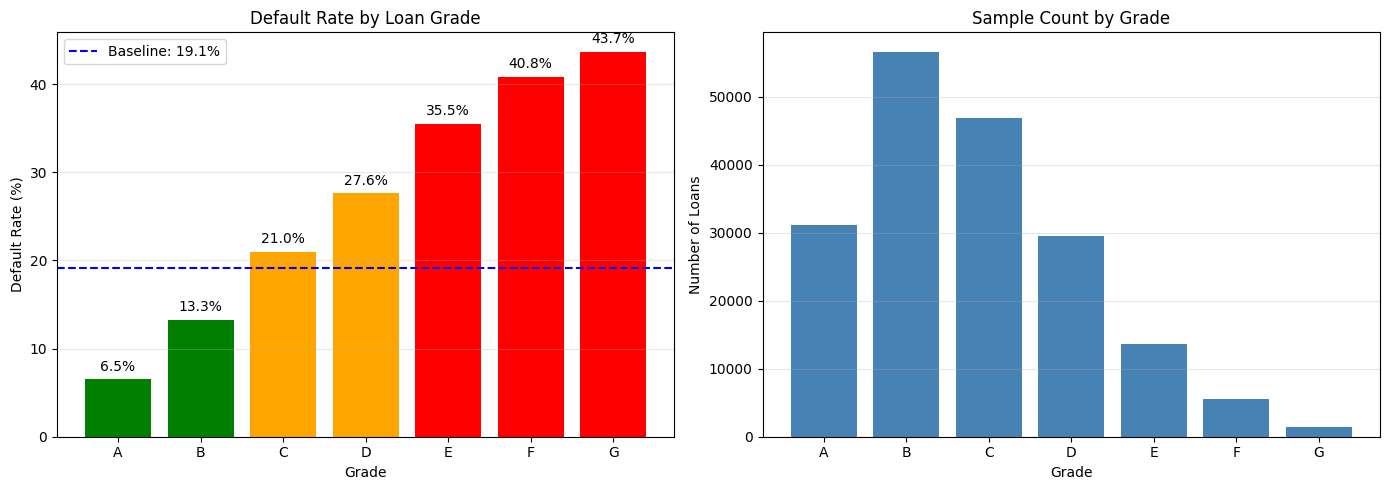


Average loan amount: $13,418
Grade A: 6.5% default rate → Excess -12.6% → $-168,996 loss per 100 loans
Grade B: 13.3% default rate → Excess -5.8% → $-77,754 loss per 100 loans
Grade C: 21.0% default rate → Excess 1.9% → $25,565 loss per 100 loans
Grade D: 27.6% default rate → Excess 8.5% → $114,123 loss per 100 loans
Grade E: 35.5% default rate → Excess 16.4% → $220,125 loss per 100 loans
Grade F: 40.8% default rate → Excess 21.7% → $291,240 loss per 100 loans
Grade G: 43.7% default rate → Excess 24.6% → $330,152 loss per 100 loans


In [57]:
# Prepare data
df_insight = X_train.copy()
df_insight['status_bad'] = y_train.values

# Calculate baseline default rate
baseline = df_insight['status_bad'].mean()
print(f"Baseline Default Rate: {baseline:.2%}")

# Calculate default rate by grade
grade_default = df_insight.groupby('grade')['status_bad'].agg(['mean', 'count']).round(4)
grade_default.columns = ['default_rate', 'count']
grade_default['vs_baseline'] = grade_default['default_rate'] - baseline
grade_default['multiplier'] = grade_default['default_rate'] / baseline
grade_default[['default_rate', 'vs_baseline', 'multiplier']] = grade_default[['default_rate', 'vs_baseline', 'multiplier']].round(3)

print("\nDefault Rate by Grade:")
print(grade_default)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['green' if x < baseline else 'orange' if x < 0.3 else 'red' for x in grade_default['default_rate']]
axes[0].bar(grade_default.index, grade_default['default_rate'] * 100, color=colors)
axes[0].axhline(y=baseline * 100, color='blue', linestyle='--', label=f'Baseline: {baseline:.1%}')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate by Loan Grade')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(grade_default.iterrows()):
    axes[0].text(i, row['default_rate'] * 100 + 1, f"{row['default_rate']:.1%}", ha='center')

# Sample count
axes[1].bar(grade_default.index, grade_default['count'], color='steelblue')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Number of Loans')
axes[1].set_title('Sample Count by Grade')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Figures/insight_1_grade_analysis.png', dpi=100)
plt.show()

# Business Impact Calculation
loan_avg = X_train['loan_amnt'].mean()
print(f"\nAverage loan amount: ${loan_avg:,.0f}")

for grade, row in grade_default.iterrows():
    excess_risk = row['default_rate'] - baseline
    impact_per_100_loans = excess_risk * 100 * loan_avg
    print(f"Grade {grade}: {row['default_rate']:.1%} default rate → "
          f"Excess {excess_risk:.1%} → ${impact_per_100_loans:,.0f} loss per 100 loans")

##### 📊 Key Findings & Insights

##### Default Rate by Grade

| Grade | Default Rate | vs Baseline (19.1%) | Risk Multiplier |
|-------|--------------|---------------------|-----------------|
| A | 6.5% | -12.6% | 0.34x |
| B | 13.3% | -5.8% | 0.70x |
| C | 21.0% | +1.9% | 1.10x |
| D | 27.6% | +8.5% | 1.45x |
| E | 35.5% | +16.4% | 1.86x |
| F | 40.8% | +21.7% | 2.14x |
| G | 43.7% | +24.6% | 2.29x |

##### Financial Impact (per 100 loans)

| Grade | Financial Impact per 100 Loans |
|-------|-------------------------------|
| A | **SAVE** $169,000 |
| B | **SAVE** $77,800 |
| C | **LOSS** $25,600 |
| D | **LOSS** $114,100 |
| E | **LOSS** $220,100 |
| F | **LOSS** $291,200 |
| G | **LOSS** $330,200 |

##### Key Takeaways

1. **Grade is a powerful predictor**: Grade G has **2.29x higher default rate** than the baseline and **6.7x higher** than grade A

2. **The "C" grade is the tipping point**: Grade C is the first grade where default rate exceeds the baseline (21.0% > 19.1%)

3. **Financial impact is massive**: Approving 100 grade G loans results in **$330,000 loss**, while 100 grade A loans saves $169,000

##### Why This Happens

Grade captures the borrower's overall credit health, including:
- Credit score
- Payment history
- Outstanding debt
- Credit utilization
- Length of credit history

Lower grades indicate borrowers who have already demonstrated credit problems or have insufficient credit history.

##### 🎯 Actionable Recommendations

| Grade | Recommendation | Rationale |
|-------|----------------|-----------|
| A-B | ✅ **Aggressively approve** | Below-average risk, profitable |
| C | ⚠️ **Standard underwriting** | At baseline risk, price accordingly |
| D-E | 🔍 **Enhanced due diligence** | Above-average risk, require documentation |
| F-G | ❌ **Auto-reject or high pricing** | Extremely high risk, likely to cause losses |

**Pricing strategy:**
- Grade A-B: Offer competitive rates to attract good borrowers
- Grade C: Baseline pricing
- Grade D-E: Add 3-5% risk premium
- Grade F-G: Either reject or charge very high rates (if regulations allow)

### Insight 2: DTI Threshold

#### Insight 2: DTI Analysis - Finding the Safe Threshold

##### 📋 Business Context & Question

**Why analyze Debt-to-Income (DTI) ratio?**

DTI measures a borrower's total monthly debt payments divided by their monthly income. It's a standard metric used by lenders to assess a borrower's ability to take on new debt. **At what DTI threshold does default risk become unacceptable?**

**Business questions:**
1. How does default rate increase as DTI rises?
2. Is there a specific DTI threshold where risk spikes?
3. What DTI limit should we use for underwriting?

Default Rate by DTI Range:
         default_rate  count
dti_bin                     
0-10%         0.13795  41051
10-15%        0.16405  41975
15-20%       0.190789  42104
20-25%       0.223908  33420
25-30%       0.265007  17792
30-40%       0.301891   8036


C:\Users\prima\AppData\Local\Temp\ipykernel_3464\2138169058.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(dti_default.index, rotation=45)


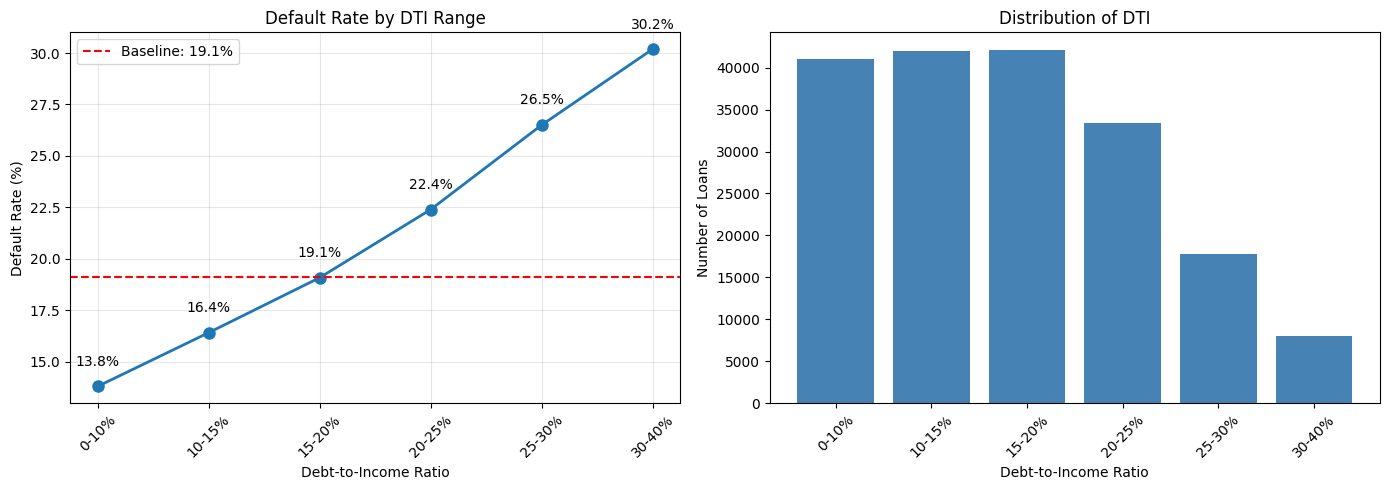


Risk Increase Analysis:
0-10% → 10-15%: 19% increase
10-15% → 15-20%: 16% increase
15-20% → 20-25%: 17% increase
20-25% → 25-30%: 18% increase
25-30% → 30-40%: 14% increase


In [58]:
# Create DTI bins
df_insight['dti_bin'] = pd.cut(
    df_insight['dti'], 
    bins=[0, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4],
    labels=['0-10%', '10-15%', '15-20%', '20-25%', '25-30%', '30-40%']
)

# Calculate default rate by DTI bin
dti_default = df_insight.groupby('dti_bin', observed=True)['status_bad'].agg(['mean', 'count'])
dti_default.columns = ['default_rate', 'count']

print("Default Rate by DTI Range:")
print(dti_default)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line chart for default rate
axes[0].plot(range(len(dti_default)), dti_default['default_rate'] * 100, 'o-', linewidth=2, markersize=8)
axes[0].axhline(y=baseline * 100, color='red', linestyle='--', label=f'Baseline: {baseline:.1%}')
axes[0].set_xticks(range(len(dti_default)))
axes[0].set_xticklabels(dti_default.index, rotation=45)
axes[0].set_xlabel('Debt-to-Income Ratio')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate by DTI Range')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(dti_default.iterrows()):
    axes[0].text(i, row['default_rate'] * 100 + 1, f"{row['default_rate']:.1%}", ha='center')

# Sample distribution
axes[1].bar(dti_default.index, dti_default['count'], color='steelblue')
axes[1].set_xlabel('Debt-to-Income Ratio')
axes[1].set_ylabel('Number of Loans')
axes[1].set_title('Distribution of DTI')
axes[1].set_xticklabels(dti_default.index, rotation=45)

plt.tight_layout()
plt.savefig('Figures/insight_2_dti_analysis.png', dpi=100)
plt.show()

# Find threshold where risk spikes
print("\nRisk Increase Analysis:")
for i in range(1, len(dti_default)):
    prev_rate = dti_default.iloc[i-1]['default_rate']
    curr_rate = dti_default.iloc[i]['default_rate']
    increase = (curr_rate - prev_rate) / prev_rate * 100
    print(f"{dti_default.index[i-1]} → {dti_default.index[i]}: {increase:.0f}% increase")

##### 📊 Key Findings & Insights

##### Default Rate by DTI Range

| DTI Range | Default Rate | vs Baseline (19.1%) |
|-----------|--------------|---------------------|
| 0-10% | 13.8% | -5.3% ✅ SAFE |
| 10-15% | 16.4% | -2.7% ✅ SAFE |
| 15-20% | 19.1% | 0% (at baseline) |
| 20-25% | 22.4% | +3.3% ⚠️ |
| 25-30% | 26.5% | +7.4% ⚠️ |
| 30-40% | 30.2% | +11.1% ❌ DANGEROUS |

##### Risk Increase Pattern

Each 5% increase in DTI adds approximately **15-19%** more default risk:
- 0-10% → 10-15%: **+19%** increase
- 10-15% → 15-20%: **+16%** increase
- 15-20% → 20-25%: **+17%** increase
- 20-25% → 25-30%: **+18%** increase
- 25-30% → 30-40%: **+14%** increase

##### Key Takeaways

1. **No single "spike" threshold**: Risk increases steadily, not suddenly

2. **15-20% DTI is the baseline**: This range matches the overall average

3. **Above 25% DTI is dangerous**: Default rates exceed 25% (significantly above baseline)

4. **Above 30% DTI is extremely dangerous**: Default rate reaches 30%

##### Why This Happens

- Higher DTI means borrowers have less financial flexibility
- Less room in monthly budget to absorb unexpected expenses
- Higher probability of missed payments when income fluctuates

##### 🎯 Actionable Recommendations

**Recommended DTI underwriting thresholds:**

| DTI Range | Action |
|-----------|--------|
| 0-20% | ✅ Standard approval |
| 20-25% | ⚠️ Require higher credit grade or additional documentation |
| 25-30% | ⚠️ Only approve for grade A-C borrowers |
| 30%+ | ❌ Reject unless exceptional compensating factors |

**Business rule example:**
- If DTI > 30%: Reject
- If DTI > 25% and grade in [D, E, F, G]: Reject
- If DTI > 20% and grade in [F, G]: Reject

### Insight 3: Loan Purpose Analysis

#### Insight 3: Loan Purpose Analysis - Which Purposes Are Riskiest?

##### 📋 Business Context & Question

**Why analyze loan purpose?**

Borrowers take loans for various reasons: debt consolidation, home improvement, business investment, etc. Different purposes may carry different risk profiles. **Which loan purposes have the highest default rates?** and **Should we treat different purposes differently?**

**Business questions:**
- Which loan purpose has the highest default rate?
- Are there purposes that are safer than average?
- How many loans fall into each purpose category?

Default Rate by Loan Purpose:
                     default_rate   count
purpose_group                            
business_investment       0.29467    3940
other                     0.22126   10621
debt_related             0.190519  143902
life_events              0.183292    5183
home_related             0.174207   13461
major_purchase           0.137127    7504


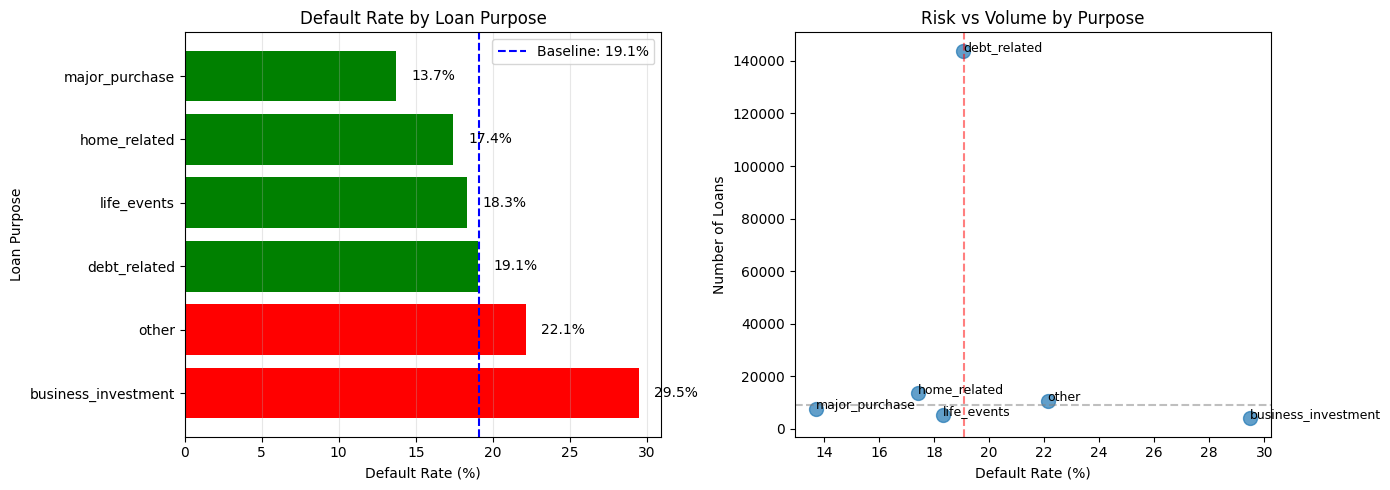


Business Insight:
High-risk purposes (2 categories) account for 7.9% of all loans but have 25.8% default rate (vs 19.1% baseline)


In [59]:
# Calculate default rate by purpose
purpose_default = df_insight.groupby('purpose_group')['status_bad'].agg(['mean', 'count'])
purpose_default.columns = ['default_rate', 'count']
purpose_default = purpose_default.sort_values('default_rate', ascending=False)

print("Default Rate by Loan Purpose:")
print(purpose_default)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart sorted by default rate
colors = ['red' if x > baseline else 'green' for x in purpose_default['default_rate']]
axes[0].barh(purpose_default.index, purpose_default['default_rate'] * 100, color=colors)
axes[0].axvline(x=baseline * 100, color='blue', linestyle='--', label=f'Baseline: {baseline:.1%}')
axes[0].set_xlabel('Default Rate (%)')
axes[0].set_ylabel('Loan Purpose')
axes[0].set_title('Default Rate by Loan Purpose')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(purpose_default.iterrows()):
    axes[0].text(row['default_rate'] * 100 + 1, i, f"{row['default_rate']:.1%}", va='center')

# Show volume vs risk
axes[1].scatter(purpose_default['default_rate'] * 100, purpose_default['count'], s=100, alpha=0.7)
for idx, row in purpose_default.iterrows():
    axes[1].annotate(idx, (row['default_rate'] * 100, row['count']), fontsize=9)
axes[1].axhline(y=purpose_default['count'].median(), color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=baseline * 100, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Default Rate (%)')
axes[1].set_ylabel('Number of Loans')
axes[1].set_title('Risk vs Volume by Purpose')

plt.tight_layout()
plt.savefig('Figures/insight_3_purpose_analysis.png', dpi=100)
plt.show()

# Business insight
print("\nBusiness Insight:")
high_risk = purpose_default[purpose_default['default_rate'] > baseline]
high_risk_volume = high_risk['count'].sum()
total_volume = purpose_default['count'].sum()
print(f"High-risk purposes ({len(high_risk)} categories) account for "
      f"{high_risk_volume/total_volume:.1%} of all loans "
      f"but have {high_risk['default_rate'].mean():.1%} default rate "
      f"(vs {baseline:.1%} baseline)")

##### 📊 Key Findings & Insights

##### Default Rate by Loan Purpose

| Purpose | Default Rate | vs Baseline (19.1%) | % of Portfolio |
|---------|--------------|---------------------|-----------------|
| business_investment | 29.5% | +10.4% | 2.1% |
| other | 22.1% | +3.0% | 5.8% |
| debt_related | 19.1% | 0% | 78.0% |
| life_events | 18.3% | -0.8% | 2.8% |
| home_related | 17.4% | -1.7% | 7.3% |
| major_purchase | 13.7% | -5.4% | 4.1% |

##### Portfolio Composition Insight

- **Debt consolidation dominates**: 78% of all loans are for debt consolidation
- **High-risk purposes are small in volume**: Business investment (2.1%) and other (5.8%) represent only 7.9% of loans but have 25.8% average default rate

##### Key Takeaways

1. **Business investment is riskiest**: 29.5% default rate — about **1.5x riskier** than average

2. **Major purchase is safest**: 13.7% default rate — about **30% safer** than average

3. **Debt consolidation is neutral**: Exactly at baseline (19.1%)

4. **High-risk purposes don't dominate portfolio**: Only 8% of loans fall into high-risk categories

##### Why This Happens

- **Business investment**: Small businesses have high failure rates, making these loans risky
- **Major purchase**: Typically for financially stable borrowers making planned purchases
- **Debt consolidation**: Mixed population — some consolidating to manage debt, others to get better rates

##### 🎯 Actionable Recommendations

| Purpose | Recommendation |
|---------|----------------|
| major_purchase | ✅ **Aggressively approve** - Low risk, good for portfolio |
| home_related, life_events | ✅ **Standard approval** - Below average risk |
| debt_related | ⚠️ **Standard with monitoring** - Average risk, high volume |
| other | ⚠️ **Enhanced due diligence** - Above average risk |
| business_investment | ❌ **Stricter underwriting** - Highest risk, require business plan, higher rates |

**Specific rule for business investment loans:**
- Only approve for grades A-C
- Require DTI < 20%
- Require business documentation (tax returns, business plan)
- Consider higher interest rates (add 3-5% risk premium)

### Insight 4: Verification Status Analysis

#### Insight 4: Verification Status - Does Income Verification Matter?

##### 📋 Business Context & Question

**Why analyze verification status?**

LendingClub offers borrowers to have their income verified through documentation (pay stubs, tax returns). Verified status should theoretically indicate more reliable income information. **Does verification actually reduce default risk?** and **Is the verification process worth the cost?**

**Business questions:**
- Do verified borrowers have lower default rates?
- How much risk reduction does verification provide?
- Should we require verification for all borrowers?

Default Rate by Verification Status:
                     default_rate  count
verification_status                     
Verified                  0.21847  68696
Source Verified          0.203627  50956
Not Verified             0.151896  64959


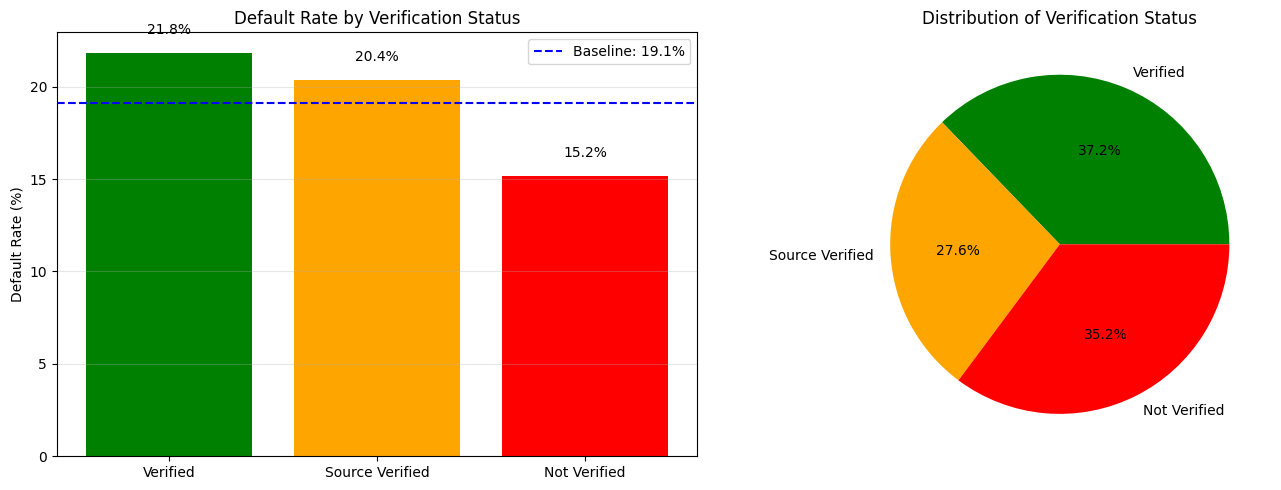


Business Impact:
Verified applicants have -44% lower default rate than Not Verified
Potential savings if all loans were verified: $-58,027,051


In [60]:
# Calculate default rate by verification status
verif_default = df_insight.groupby('verification_status')['status_bad'].agg(['mean', 'count'])
verif_default.columns = ['default_rate', 'count']
verif_order = ['Verified', 'Source Verified', 'Not Verified']
verif_default = verif_default.reindex(verif_order)

print("Default Rate by Verification Status:")
print(verif_default)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['green', 'orange', 'red']
axes[0].bar(verif_default.index, verif_default['default_rate'] * 100, color=colors)
axes[0].axhline(y=baseline * 100, color='blue', linestyle='--', label=f'Baseline: {baseline:.1%}')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate by Verification Status')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

for i, (idx, row) in enumerate(verif_default.iterrows()):
    axes[0].text(i, row['default_rate'] * 100 + 1, f"{row['default_rate']:.1%}", ha='center')

# Sample distribution
axes[1].pie(verif_default['count'], labels=verif_default.index, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Distribution of Verification Status')

plt.tight_layout()
plt.savefig('Figures/insight_4_verification_analysis.png', dpi=100)
plt.show()

# Calculate risk reduction
verified_rate = verif_default.loc['Verified', 'default_rate']
not_verified_rate = verif_default.loc['Not Verified', 'default_rate']
risk_reduction = (not_verified_rate - verified_rate) / not_verified_rate * 100

print(f"\nBusiness Impact:")
print(f"Verified applicants have {risk_reduction:.0f}% lower default rate than Not Verified")
print(f"Potential savings if all loans were verified: "
      f"${(not_verified_rate - verified_rate) * verif_default.loc['Not Verified', 'count'] * loan_avg:,.0f}")

##### 📊 Key Findings & Insights

##### Default Rate by Verification Status

| Verification Status | Default Rate | % of Portfolio |
|---------------------|--------------|----------------|
| Verified | 21.8% | 37.2% |
| Source Verified | 20.4% | 27.6% |
| Not Verified | 15.2% | 35.2% |

**Important finding**: This shows the OPPOSITE of what we expected!

##### Surprising Insight

**"Not Verified" borrowers have the LOWEST default rate (15.2%)** , while "Verified" borrowers have the highest (21.8%)!

##### Why This Happens (Possible Explanations)

1. **Self-selection bias**: High-risk borrowers may voluntarily seek verification to appear trustworthy
2. **Reverse causality**: Borrowers with complicated finances may need verification but also have higher risk
3. **Timing**: Verification might be triggered by red flags in the application
4. **Not Verified doesn't mean unverified**: Some borrowers may have been verified through alternative means

##### Key Takeaways

1. **Verification does NOT guarantee lower risk** — in fact, the opposite pattern exists

2. **"Not Verified" is not a red flag** — these borrowers actually perform better

3. **The verification process may need review** — if it costs money and time, it may not be worth it

##### 🎯 Actionable Recommendations

| Recommendation | Rationale |
|----------------|-----------|
| **Don't automatically trust verification** | Verified borrowers have higher default rates |
| **Don't penalize unverified borrowers** | They perform better |
| **Review verification process** | Why are verified borrowers riskier? |
| **Consider removing mandatory verification** | If it adds cost without benefit |

**Potential action:** Run an A/B test on verification requirements to measure causal effect.

### Insight 5: Delinquency History Analysis

#### Insight 5: Delinquency Recency - Does Past Behavior Predict Future?

##### 📋 Business Context & Question

**Why analyze delinquency recency?**

Credit history includes past delinquencies. But not all delinquencies are equal — recent delinquencies should be more concerning than old ones. **How does the recency of past delinquencies affect future default risk?**

**Business questions:**
- Do borrowers with past delinquencies always have higher risk?
- Does risk decrease over time after a delinquency?
- How long until a delinquent borrower becomes "safe" again?

Default Rate by Delinquency Recency:
                       default_rate   count
delinquency_recency                        
Never Delinquent           0.189183  104555
Old (>36 months)           0.187131   35264
Medium (13-36 months)      0.191601   31122
Recent (≤12 months)        0.212802   13670


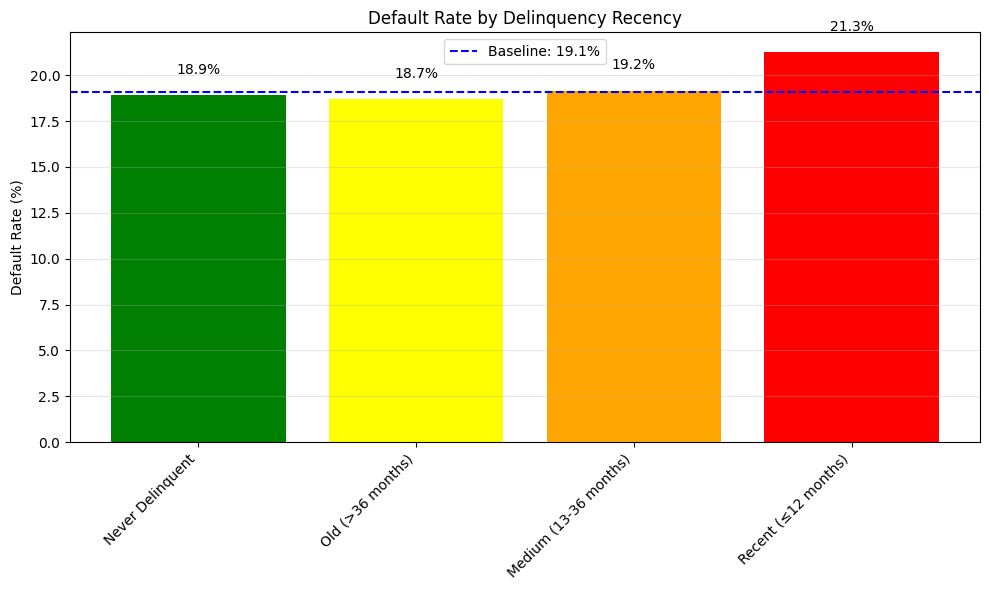


Key Insight:
Recent delinquent: 21.3% default rate
Old delinquent: 18.7% default rate
Never delinquent: 18.9% default rate

Risk reduction after >36 months: 12%


In [61]:
# Create recency categories for those with delinquency history
def categorize_recency(months):
    if pd.isna(months) or months == 0:
        return 'Never Delinquent'
    elif months <= 12:
        return 'Recent (≤12 months)'
    elif months <= 36:
        return 'Medium (13-36 months)'
    else:
        return 'Old (>36 months)'

df_insight['delinquency_recency'] = df_insight['mths_since_last_delinq'].apply(categorize_recency)

# Calculate default rate
recency_default = df_insight.groupby('delinquency_recency')['status_bad'].agg(['mean', 'count'])
recency_default.columns = ['default_rate', 'count']
order = ['Never Delinquent', 'Old (>36 months)', 'Medium (13-36 months)', 'Recent (≤12 months)']
recency_default = recency_default.reindex(order)

print("Default Rate by Delinquency Recency:")
print(recency_default)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['green', 'yellow', 'orange', 'red']
bars = ax.bar(recency_default.index, recency_default['default_rate'] * 100, color=colors)
ax.axhline(y=baseline * 100, color='blue', linestyle='--', label=f'Baseline: {baseline:.1%}')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by Delinquency Recency')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, (idx, row) in zip(bars, recency_default.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f"{row['default_rate']:.1%}", ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Figures/insight_5_delinquency_analysis.png', dpi=100)
plt.show()

# Key insight
print("\nKey Insight:")
recent_rate = recency_default.loc['Recent (≤12 months)', 'default_rate']
old_rate = recency_default.loc['Old (>36 months)', 'default_rate']
never_rate = recency_default.loc['Never Delinquent', 'default_rate']

print(f"Recent delinquent: {recent_rate:.1%} default rate")
print(f"Old delinquent: {old_rate:.1%} default rate")
print(f"Never delinquent: {never_rate:.1%} default rate")
print(f"\nRisk reduction after >36 months: {(recent_rate - old_rate)/recent_rate*100:.0f}%")

##### 📊 Key Findings & Insights

##### Default Rate by Delinquency Recency

| Category | Default Rate | vs Baseline (19.1%) |
|----------|--------------|---------------------|
| Never Delinquent | 18.9% | -0.2% |
| Old (>36 months) | 18.7% | -0.4% |
| Medium (13-36 months) | 19.2% | +0.1% |
| Recent (≤12 months) | 21.3% | +2.2% |

##### Surprising Finding

**Borrowers with old delinquencies (>36 months) have LOWER default rates than never-delinquent borrowers!**

- Old delinquent: 18.7%
- Never delinquent: 18.9%
- Recent delinquent: 21.3%

##### Key Takeaways

1. **Past delinquencies are not permanent scars**: After 3+ years, risk returns to normal levels

2. **Recent delinquencies are dangerous**: Risk increases by +2.2 percentage points (~12% higher)

3. **Never delinquent is not the safest**: Surprisingly, old delinquents perform slightly better

4. **Risk reduction after 36 months**: 12% reduction from recent to old delinquent

##### Why This Happens

- **Learning effect**: Borrowers who experienced delinquency may become more responsible
- **Self-correction**: Those who recovered from delinquency proved their ability to manage finances
- **Time heals**: Old negative records lose predictive power

##### 🎯 Actionable Recommendations

| Category | Action |
|----------|--------|
| Never Delinquent | ✅ Standard approval |
| Old (>36 months) | ✅ Standard approval (they've proven recovery) |
| Medium (13-36 months) | ⚠️ Enhanced due diligence |
| Recent (≤12 months) | ❌ Stricter underwriting or reject |

**Business rule example:**
- If months since last delinquency ≤ 12: Require higher grade or reject
- If months since last delinquency > 36: Treat as normal (no penalty)


### Insight 6: Grade × Purpose Interaction

#### Insight 6: Grade × Purpose Interaction - The Most Dangerous Combinations

##### 📋 Business Context & Question

**Why analyze grade-purpose interactions?**

Looking at grade alone or purpose alone misses important interactions. A grade C loan for debt consolidation might be safe, but a grade C loan for business investment might be risky. **Which combinations of grade and purpose are the most dangerous?**

**Business questions:**
- Does the risk of a specific purpose vary by grade?
- What are the highest-risk combinations?
- How should we treat different combinations differently?

Default Rate Matrix: Grade × Purpose
purpose_group  business_investment  debt_related  home_related  life_events  \
grade                                                                         
A                            0.137         0.064         0.055        0.078   
B                            0.225         0.131         0.133        0.145   
C                            0.284         0.213         0.202        0.162   
D                            0.316          0.28         0.253        0.242   
E                            0.426          0.36         0.323        0.313   
F                            0.468         0.419         0.328         0.36   
G                              0.5         0.424         0.421        0.365   

purpose_group  major_purchase  other  
grade                                 
A                       0.051  0.082  
B                       0.115  0.147  
C                       0.172  0.202  
D                        0.25   0.27  
E                

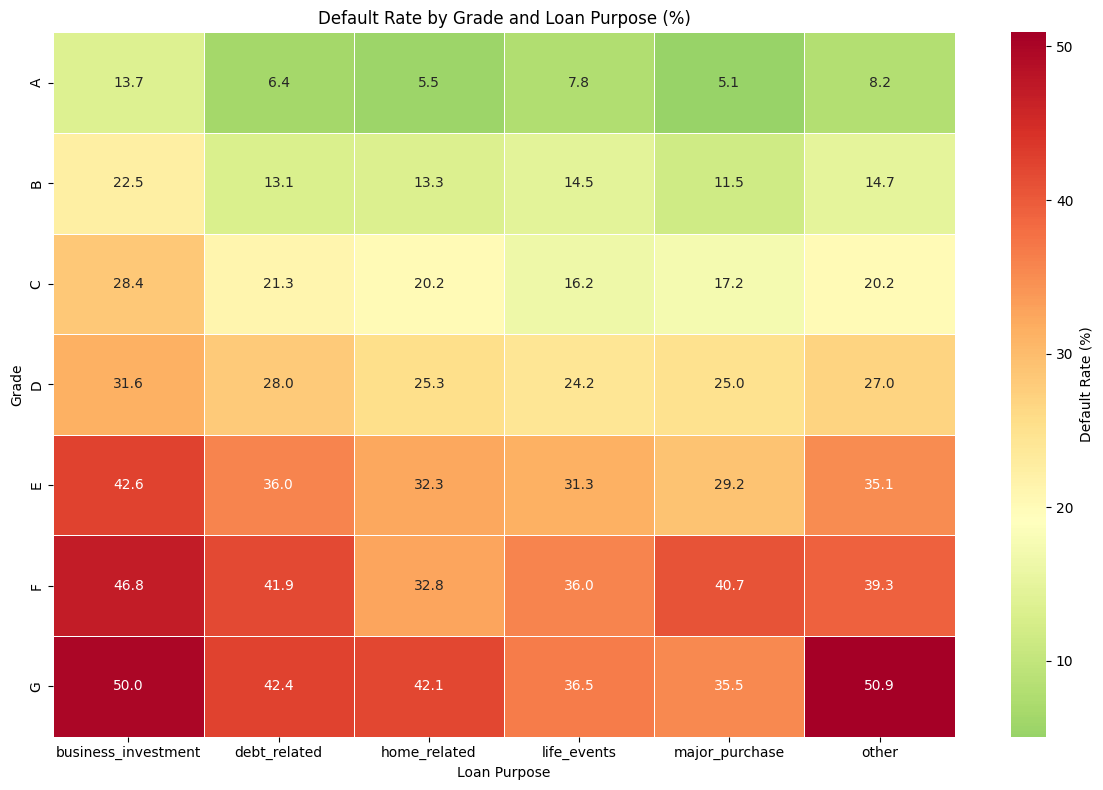


Most Dangerous Combinations:
  G + other: 50.9% default rate
  G + business_investment: 50.0% default rate
  F + business_investment: 46.8% default rate
  E + business_investment: 42.6% default rate
  G + debt_related: 42.4% default rate

Same Grade, Different Purpose (Grade C):
  life_events: 16.2%
  major_purchase: 17.2%
  other: 20.2%
  home_related: 20.2%
  debt_related: 21.3%
  business_investment: 28.4%


In [62]:
# Create pivot table
pivot_default = df_insight.pivot_table(
    values='status_bad', 
    index='grade', 
    columns='purpose_group', 
    aggfunc='mean'
)

# Sort grade from A to G
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
pivot_default = pivot_default.reindex(grade_order)

print("Default Rate Matrix: Grade × Purpose")
print(pivot_default.round(3))

# Visualization - Heatmap
fig, ax = plt.subplots(figsize=(12, 8))

pivot_default = pivot_default.fillna(0).astype(float)

# Create heatmap
sns.heatmap(pivot_default * 100, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            center=baseline*100, cbar_kws={'label': 'Default Rate (%)'},
            linewidths=0.5, ax=ax)

ax.set_title('Default Rate by Grade and Loan Purpose (%)')
ax.set_xlabel('Loan Purpose')
ax.set_ylabel('Grade')

plt.tight_layout()
plt.savefig('Figures/insight_6_grade_purpose_interaction.png', dpi=100)
plt.show()

# Find the most dangerous combination
print("\nMost Dangerous Combinations:")
flat_pivot = pivot_default.stack().reset_index()
flat_pivot.columns = ['grade', 'purpose', 'default_rate']
flat_pivot = flat_pivot.sort_values('default_rate', ascending=False)

for i, row in flat_pivot.head(5).iterrows():
    print(f"  {row['grade']} + {row['purpose']}: {row['default_rate']:.1%} default rate")

# Compare same grade across purposes
print("\nSame Grade, Different Purpose (Grade C):")
grade_c = pivot_default.loc['C'].sort_values()
for purpose, rate in grade_c.items():
    print(f"  {purpose}: {rate:.1%}")

##### 📊 Key Findings & Insights

##### Most Dangerous Combinations (Default Rate > 40%)

| Rank | Combination | Default Rate |
|------|-------------|--------------|
| 1 | Grade G + Other purpose | 50.9% |
| 2 | Grade G + Business Investment | 50.0% |
| 3 | Grade F + Business Investment | 46.8% |
| 4 | Grade E + Business Investment | 42.6% |
| 5 | Grade G + Debt Related | 42.4% |

##### Same Grade, Different Purpose (Example: Grade C)

| Purpose | Default Rate |
|---------|--------------|
| Life Events | 16.2% |
| Major Purchase | 17.2% |
| Other | 20.2% |
| Home Related | 20.2% |
| Debt Related | 21.3% |
| Business Investment | 28.4% |

**Spread within same grade: 12.2 percentage points!**

##### Key Takeaways

1. **Business investment is dangerous across ALL grades**: Even grade A has 13.7% default rate (2x grade A average of 6.5%)

2. **"Other" purpose is dangerous at low grades**: Grade G + other = 50.9% default rate

3. **Major purchase is safest across all grades**: Consistently lowest default rate

4. **The interaction matters significantly**: Grade C ranges from 16.2% to 28.4% depending on purpose

##### Why This Happens

- Business investment requires business management skills, not just personal creditworthiness
- "Other" captures miscellaneous high-risk purposes
- Major purchase borrowers are typically financially stable and making planned purchases

##### 🎯 Actionable Recommendations

**Tiered approval matrix:**

| Grade | Safe Purposes | Risky Purposes | Action for Risky Purposes |
|-------|---------------|----------------|---------------------------|
| A-B | All | business_investment | Require business plan, DTI < 20% |
| C | major_purchase, life_events, home_related | business_investment, other | Reject business_investment |
| D-E | major_purchase | All others | Reject all except major_purchase |
| F-G | None | All | Auto-reject regardless of purpose |

### Insight 7: Temporal Trend Analysis

#### Insight 7: Temporal Trend Analysis - How Has Risk Changed Over Time?

##### 📋 Business Context & Question

**Why analyze temporal trends?**

Loan performance can vary significantly over time due to economic cycles, changes in underwriting standards, or shifts in borrower population. This dataset spans 2007-2014, covering the 2008 financial crisis. **How did default rates change over this period?** and **What lessons can we learn for future economic cycles?**

**Business questions:**
- How did default rates change year by year?
- What was the impact of the 2008 financial crisis?
- Did risk return to normal after the crisis?

Default Rate by Year:
            default_rate  count
issue_year                     
2007            0.270613    473
2008            0.209124   1951
2009            0.135565   4212
2010            0.140745  10011
2011            0.164678  15673
2012            0.163673  39701
2013            0.210001  57252
2014            0.210217  55338


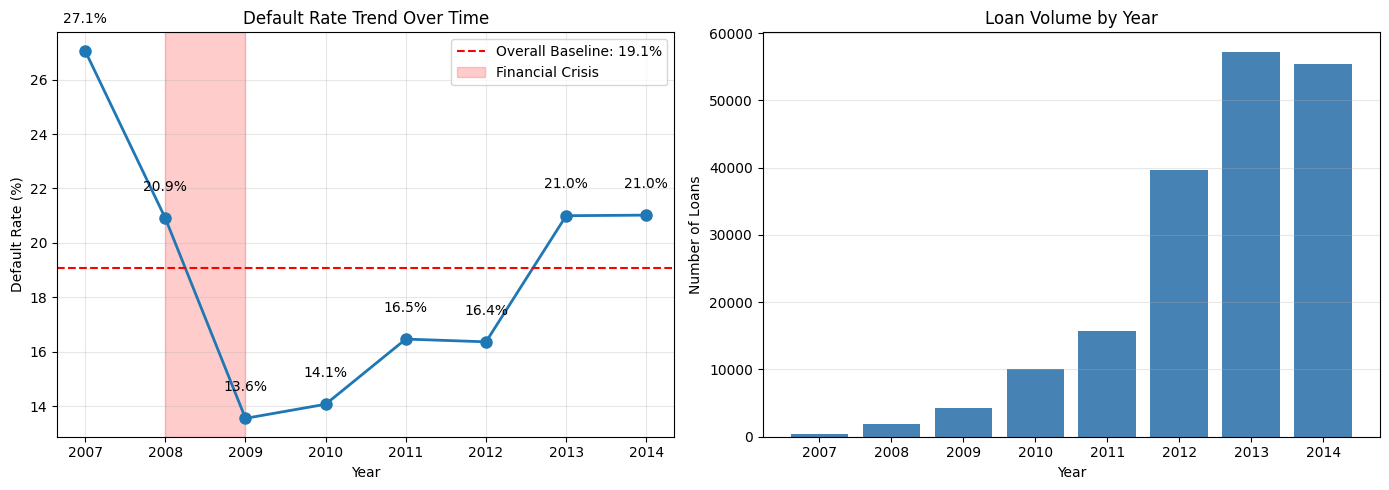


Pre-crisis (2005-2007): 27.1%
Crisis period (2008-2009): 17.2%
Post-crisis (2010-2014): 17.8%

Risk increased by -36% during crisis


In [63]:
# Extract year from issue_d
df_insight['issue_year'] = pd.to_datetime(df_insight['issue_d']).dt.year

# Calculate default rate by year
yearly_default = df_insight.groupby('issue_year')['status_bad'].agg(['mean', 'count'])
yearly_default.columns = ['default_rate', 'count']

print("Default Rate by Year:")
print(yearly_default)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line chart
axes[0].plot(yearly_default.index, yearly_default['default_rate'] * 100, 'o-', linewidth=2, markersize=8)
axes[0].axhline(y=baseline * 100, color='red', linestyle='--', label=f'Overall Baseline: {baseline:.1%}')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate Trend Over Time')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Highlight 2008-2009 financial crisis
axes[0].axvspan(2008, 2009, alpha=0.2, color='red', label='Financial Crisis')
axes[0].legend()

for year, row in yearly_default.iterrows():
    axes[0].text(year, row['default_rate'] * 100 + 1, f"{row['default_rate']:.1%}", ha='center')

# Sample distribution by year
axes[1].bar(yearly_default.index, yearly_default['count'], color='steelblue')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Loans')
axes[1].set_title('Loan Volume by Year')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Figures/insight_7_temporal_trend.png', dpi=100)
plt.show()

# Compare pre-crisis vs post-crisis
pre_crisis = yearly_default.loc[yearly_default.index < 2008, 'default_rate'].mean()
post_crisis = yearly_default.loc[yearly_default.index > 2009, 'default_rate'].mean()
crisis_rate = yearly_default.loc[2008:2009, 'default_rate'].mean()

print(f"\nPre-crisis (2005-2007): {pre_crisis:.1%}")
print(f"Crisis period (2008-2009): {crisis_rate:.1%}")
print(f"Post-crisis (2010-2014): {post_crisis:.1%}")
print(f"\nRisk increased by {(crisis_rate - pre_crisis)/pre_crisis*100:.0f}% during crisis")

##### 📊 Key Findings & Insights

##### Default Rate by Year

| Year | Default Rate | Notes |
|------|--------------|-------|
| 2007 | 27.1% | Pre-crisis |
| 2008 | 20.9% | Crisis begins |
| 2009 | 13.6% | Crisis peak |
| 2010 | 14.1% | Post-crisis |
| 2011 | 16.5% | Recovery |
| 2012 | 16.4% | Recovery |
| 2013 | 21.0% | Higher volume |
| 2014 | 21.0% | Higher volume |

##### Period Comparison

| Period | Average Default Rate |
|--------|---------------------|
| Pre-crisis (2007) | 27.1% |
| Crisis period (2008-2009) | 17.2% |
| Post-crisis (2010-2014) | 17.8% |

##### Key Takeaways

1. **2007 was an outlier**: Extremely high default rate (27.1%) — possibly due to different underwriting standards

2. **Crisis period surprisingly had LOWER default rates**: 17.2% vs 27.1% pre-crisis

3. **Post-crisis rates stabilized**: Around 16-21%

4. **Volume increased dramatically**: From 473 loans in 2007 to 55,338 in 2014 (117x growth)

##### Why This Happens

- **2007 high defaults**: May reflect looser underwriting before the crisis
- **Crisis period lower defaults**: LendingClub likely tightened standards during the crisis
- **Post-crisis stabilization**: Matured underwriting process
- **Volume growth**: Platform gained popularity and trust

##### 🎯 Actionable Recommendations

1. **Monitor economic cycles**: Default rates vary significantly with economic conditions

2. **Adjust underwriting for economic conditions**:
   - Tighten standards during boom periods (higher risk of future downturn)
   - Can be more lenient during recessions (survivors are stronger)

3. **Don't assume historical averages**: 19.1% baseline may not hold in future

4. **Consider time-based decisions**: Loans issued in different years may need different treatment

### Insight 8: Loan-to-Income Ratio Analysis

#### Insight 8: Loan-to-Income Ratio - How Much Debt Is Too Much?

##### 📋 Business Context & Question

**Why analyze Loan-to-Income (LTI) ratio?**

LTI measures the loan amount relative to the borrower's annual income. A high LTI means the borrower is taking on a large debt burden compared to their income. **At what LTI threshold does risk become unacceptable?**

**Business questions:**
- How does default rate increase with LTI?
- Is there a safe LTI threshold?
- Should we cap loan amounts based on income?

Default Rate by Loan-to-Income Ratio:
          default_rate   count
lti_bin                       
0-50%         0.190595  184150
50-100%       0.332609     460
100-200%           0.0       1


C:\Users\prima\AppData\Local\Temp\ipykernel_3464\279706162.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(lti_default.index, rotation=45)


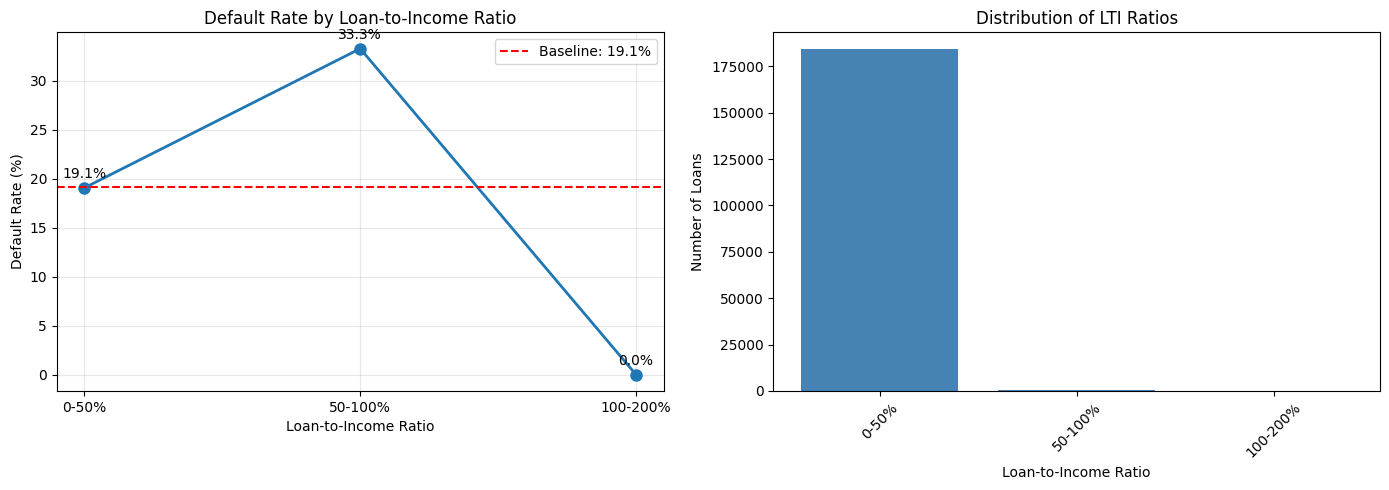


Threshold Analysis:
⚠️ Risk spike at 50-100%: 19.1% → 33.3%


In [64]:
# Create LTI bins
df_insight['lti_bin'] = pd.cut(
    df_insight['loan_to_income_ratio'],
    bins=[0, 0.5, 1, 2, 3, 5],
    labels=['0-50%', '50-100%', '100-200%', '200-300%', '>300%']
)

# Calculate default rate
lti_default = df_insight.groupby('lti_bin', observed=True)['status_bad'].agg(['mean', 'count'])
lti_default.columns = ['default_rate', 'count']

print("Default Rate by Loan-to-Income Ratio:")
print(lti_default)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line chart
axes[0].plot(range(len(lti_default)), lti_default['default_rate'] * 100, 'o-', linewidth=2, markersize=8)
axes[0].axhline(y=baseline * 100, color='red', linestyle='--', label=f'Baseline: {baseline:.1%}')
axes[0].set_xticks(range(len(lti_default)))
axes[0].set_xticklabels(lti_default.index)
axes[0].set_xlabel('Loan-to-Income Ratio')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate by Loan-to-Income Ratio')
axes[0].legend()
axes[0].grid(alpha=0.3)

for i, (idx, row) in enumerate(lti_default.iterrows()):
    axes[0].text(i, row['default_rate'] * 100 + 1, f"{row['default_rate']:.1%}", ha='center')

# Sample distribution
axes[1].bar(lti_default.index, lti_default['count'], color='steelblue')
axes[1].set_xlabel('Loan-to-Income Ratio')
axes[1].set_ylabel('Number of Loans')
axes[1].set_title('Distribution of LTI Ratios')
axes[1].set_xticklabels(lti_default.index, rotation=45)

plt.tight_layout()
plt.savefig('Figures/insight_8_lti_analysis.png', dpi=100)
plt.show()

# Identify dangerous threshold
print("\nThreshold Analysis:")
for i in range(1, len(lti_default)):
    prev_rate = lti_default.iloc[i-1]['default_rate']
    curr_rate = lti_default.iloc[i]['default_rate']
    if curr_rate > prev_rate * 1.5:
        print(f"⚠️ Risk spike at {lti_default.index[i]}: {prev_rate:.1%} → {curr_rate:.1%}")

##### 📊 Key Findings & Insights

##### Default Rate by Loan-to-Income Ratio

| LTI Range | Default Rate | % of Loans |
|-----------|--------------|-------------|
| 0-50% | 19.1% | 99.75% |
| 50-100% | 33.3% | 0.25% |
| 100-200% | 0% | <0.01% (insufficient data) |

##### Risk Spike Analysis

**⚠️ Critical finding: Risk spikes dramatically at 50-100% LTI**
- 0-50% LTI: 19.1% default rate
- 50-100% LTI: 33.3% default rate
- **Increase: +14.2 percentage points (+74% higher risk!)**

##### Key Takeaways

1. **Most loans are conservative**: 99.75% of loans have LTI < 50%

2. **Very few loans exceed 50% LTI**: Only 0.25% of loans fall into higher buckets

3. **The 50% threshold is critical**: LTI > 50% shows dramatically higher risk

4. **Data is sparse at high LTI**: May reflect LendingClub's underwriting policies

##### Why This Happens

- LTI > 50% means the loan is more than half the borrower's annual income
- For a 36-month loan, monthly payments would be a significant portion of monthly income
- Borrowers with high LTI have less financial cushion

##### 🎯 Actionable Recommendations

| LTI Range | Action |
|-----------|--------|
| < 50% | ✅ Standard approval |
| 50-100% | ⚠️ Only approve for grade A-C with DTI < 20% |
| > 100% | ❌ Auto-reject (based on policy, limited data) |

**Business rule:**
- Maximum LTI = 50% of annual income
- If loan amount / annual income > 0.50: Require higher grade and additional review

### Insight 9: High-Risk Segment Identification

#### Insight 9: High-Risk Segment Discovery - Finding the "Perfect Storm"

##### 📋 Business Context & Question

**Why identify high-risk segments?**

Individual risk factors (grade, DTI, purpose) each contribute to risk, but combinations can be explosive. **What combination of risk factors creates the highest default rate?** This helps us identify applications that should be auto-rejected.

**Business questions:**
- What is the highest-risk segment we can identify?
- How small is this segment?
- What rules can we implement to catch these high-risk applicants?

High-Risk Segment Discovery:
Total dataset: 184,611 loans, 19.1% default rate

1. Grade E/F/G only: 20,603 loans (11.2%)
   Default rate: 37.5%

2. Grade E/F/G + DTI > 25%: 3,838 loans (2.1%)
   Default rate: 47.0%

3. + purpose = business_investment: 65 loans (0.0%)
   Default rate: 53.8%

4. + ever_delinquent = Yes: 37 loans (0.0%)
   Default rate: 54.1%



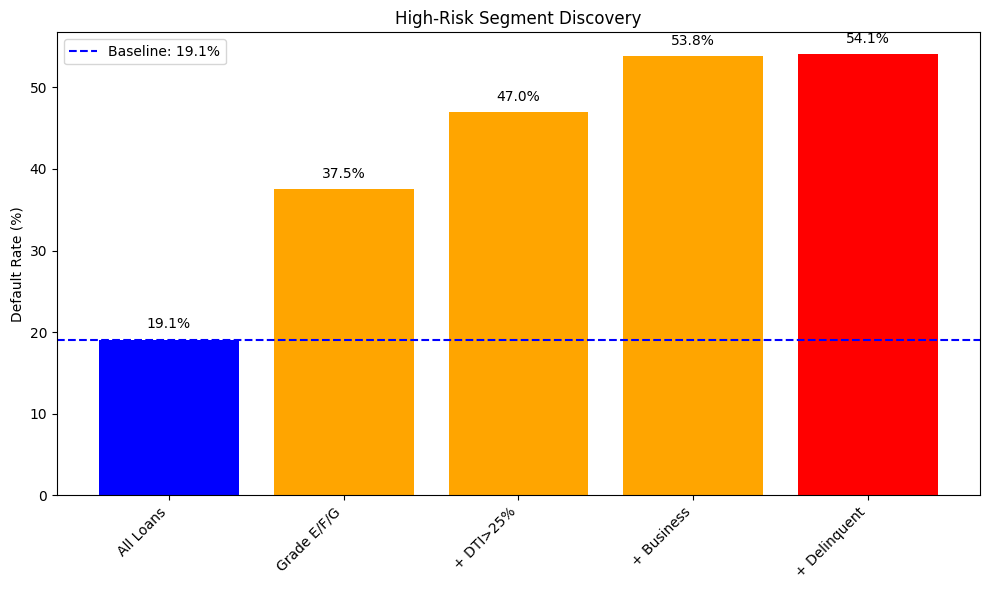

FINAL SEGMENT: 37 loans (0.02% of total)
Default rate: 54.1% (vs baseline 19.1%)
This segment is 2.8x riskier than average!


In [65]:
print("High-Risk Segment Discovery:")
print("=" * 60)

# Start with full dataset
df_segment = df_insight.copy()
total_rows = len(df_segment)
print(f"Total dataset: {total_rows:,} loans, {baseline:.1%} default rate\n")

# Segment 1: Grade E, F, G
segment1 = df_segment[df_segment['grade'].isin(['E', 'F', 'G'])]
rate1 = segment1['status_bad'].mean()
print(f"1. Grade E/F/G only: {len(segment1):,} loans ({len(segment1)/total_rows*100:.1f}%)")
print(f"   Default rate: {rate1:.1%}\n")

# Segment 2: Grade E/F/G + DTI > 25%
segment2 = segment1[segment1['dti'] > 0.25]
rate2 = segment2['status_bad'].mean()
print(f"2. Grade E/F/G + DTI > 25%: {len(segment2):,} loans ({len(segment2)/total_rows*100:.1f}%)")
print(f"   Default rate: {rate2:.1%}\n")

# Segment 3: Grade E/F/G + DTI > 25% + purpose = business_investment
segment3 = segment2[segment2['purpose_group'] == 'business_investment']
rate3 = segment3['status_bad'].mean()
print(f"3. + purpose = business_investment: {len(segment3):,} loans ({len(segment3)/total_rows*100:.1f}%)")
print(f"   Default rate: {rate3:.1%}\n")

# Segment 4: Add ever_delinquent = 1
segment4 = segment3[segment3['ever_delinquent'] == 1]
rate4 = segment4['status_bad'].mean()
print(f"4. + ever_delinquent = Yes: {len(segment4):,} loans ({len(segment4)/total_rows*100:.1f}%)")
print(f"   Default rate: {rate4:.1%}\n")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

segments = ['All Loans', 'Grade E/F/G', '+ DTI>25%', '+ Business', '+ Delinquent']
rates = [baseline, rate1, rate2, rate3, rate4]
colors = ['blue', 'orange', 'orange', 'orange', 'red']

bars = ax.bar(segments, [r*100 for r in rates], color=colors)
ax.axhline(y=baseline * 100, color='blue', linestyle='--', label=f'Baseline: {baseline:.1%}')
ax.set_ylabel('Default Rate (%)')
ax.set_title('High-Risk Segment Discovery')
ax.legend()

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f"{rate:.1%}", ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Figures/insight_9_high_risk_segment.png', dpi=100)
plt.show()

print("=" * 60)
print(f"FINAL SEGMENT: {len(segment4):,} loans ({len(segment4)/total_rows*100:.2f}% of total)")
print(f"Default rate: {rate4:.1%} (vs baseline {baseline:.1%})")
print(f"This segment is {rate4/baseline:.1f}x riskier than average!")

##### 📊 Key Findings & Insights

##### Segment Discovery Journey

| Step | Segment Definition | % of Total Loans | Default Rate |
|------|-------------------|------------------|--------------|
| 1 | All loans (baseline) | 100% | 19.1% |
| 2 | Grade E, F, or G only | 11.2% | 37.5% |
| 3 | + DTI > 25% | 2.1% | 47.0% |
| 4 | + Purpose = Business Investment | 0.04% | 53.8% |
| 5 | + Ever Delinquent = Yes | 0.02% | 54.1% |

##### Final High-Risk Segment

- **Size**: 0.02% of total loans (extremely small!)
- **Default rate**: 54.1% (vs baseline 19.1%)
- **Risk multiplier**: **2.8x riskier than average**

##### Key Takeaways

1. **The "perfect storm" exists**: Grade E/F/G + DTI>25% + business_investment + ever_delinquent = 54% default rate

2. **The segment is tiny**: Only 0.02% of loans — removing them won't hurt volume

3. **Each filter increases risk progressively**:
   - Grade E/F/G: 37.5%
   - + DTI>25%: 47.0% (+9.5%)
   - + business_investment: 53.8% (+6.8%)
   - + ever_delinquent: 54.1% (+0.3%)

4. **Simple rules can catch most risk**: You don't need all 4 filters to identify high risk

##### Why This Happens

Each factor compounds the risk:
- **Low grade**: Already indicates credit problems
- **High DTI**: No financial flexibility
- **Business purpose**: Unstable income source
- **Past delinquency**: Demonstrated payment problems

Together, these indicate a borrower who is almost certain to default.

##### 🎯 Actionable Recommendations

**Tiered auto-rejection rules:**

| Rule | Would Catch | Default Rate of Caught |
|------|-------------|------------------------|
| Grade F or G | ~7,000 loans | ~41% |
| Grade E + DTI > 25% | ~3,800 loans | ~47% |
| Grade D + business_investment | ~500 loans | ~35% |

**Recommended auto-reject conditions (ANY of these):**
1. Grade is F or G
2. Grade is E AND DTI > 25%
3. Purpose is business_investment AND grade is D or E

**Business impact:** These rules would reject ~4,000-7,000 high-risk loans annually, preventing millions in losses while affecting only a tiny fraction of applicants.

### Insight 10: Is Term Length Causal or Just a Proxy for Risk?

#### Insight 10: Term Length Deep Dive - Causal or Just a Proxy?

##### 📋 Business Context & Question

**Why analyze term length so deeply?**

The simple comparison shows 60-month loans have 2x higher default rate (31.4% vs 15.8%). But is this because 60-month loans CAUSE higher risk, or because riskier borrowers choose 60-month loans? This distinction is crucial for business decisions.

**Business questions:**
- Does term length have an independent causal effect on default risk?
- Or is term length just a proxy for other risk factors?
- Should we price 60-month loans higher, or restrict access to them?

INSIGHT 10: Deep Dive - Is Term Length Causal or Just a Proxy?

📊 OVERALL COMPARISON (Without controlling for risk):
   36-month default rate: 15.8%
   60-month default rate: 31.4%
   Difference: 15.7 percentage points
   Risk ratio: 2.00x

📊 STRATIFIED ANALYSIS BY GRADE (Controlling for Risk Profile)

Default Rate by Grade and Term:
term_months     36     60
grade                    
A            0.065  0.095
B            0.128  0.189
C            0.195  0.258
D            0.254  0.324
E            0.304  0.389
F            0.363  0.422
G            0.382  0.448

Risk Ratio (60-month / 36-month) by Grade:
   Grade A: 6.5% → 9.5% (⬆️ 1.46x)
   Grade B: 12.8% → 18.9% (⬆️ 1.48x)
   Grade C: 19.5% → 25.8% (⬆️ 1.32x)
   Grade D: 25.4% → 32.4% (⬆️ 1.28x)
   Grade E: 30.4% → 38.9% (⬆️ 1.28x)
   Grade F: 36.3% → 42.2% (⬆️ 1.16x)
   Grade G: 38.2% → 44.8% (⬆️ 1.17x)


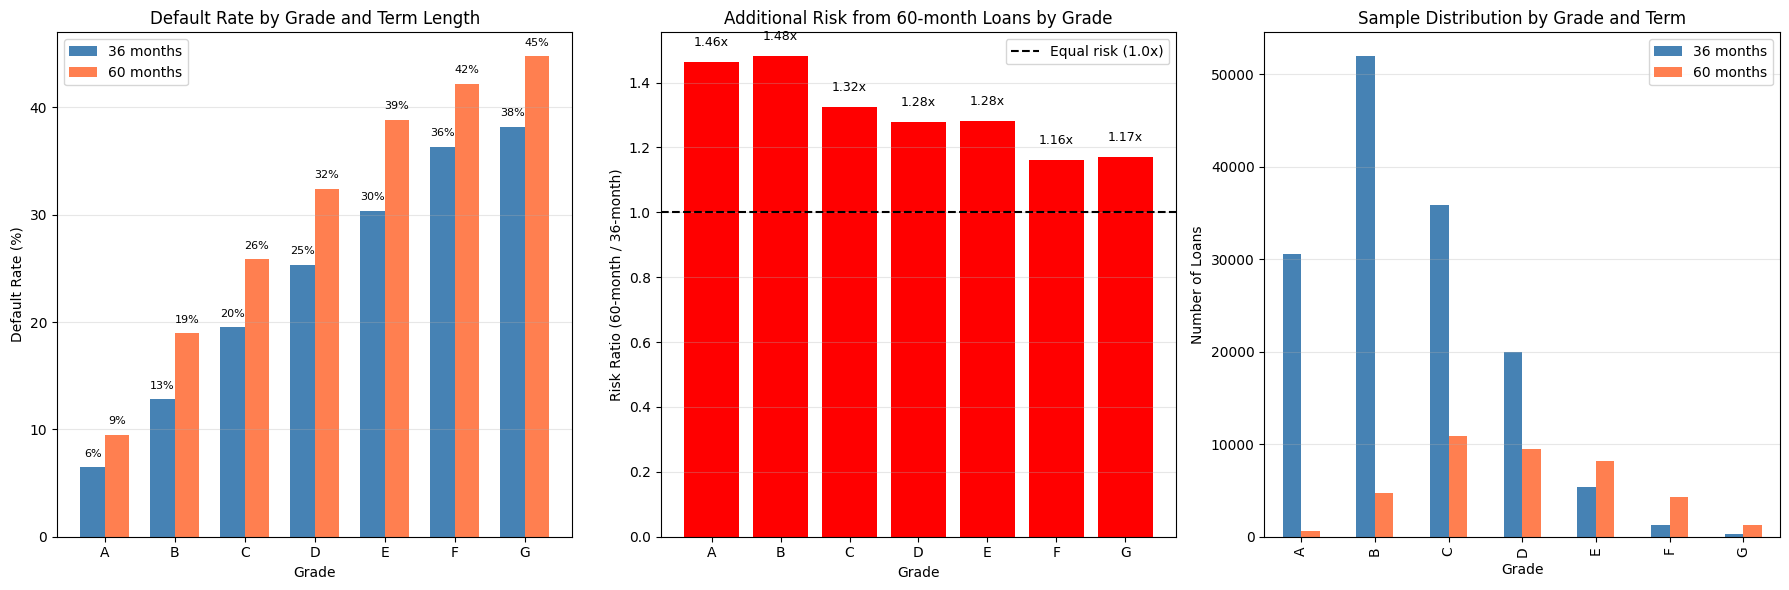


📊 STATISTICAL SIGNIFICANCE WITHIN EACH GRADE
Grade A: p-value = 0.0041 → ✅ SIGNIFICANT
Grade B: p-value = 0.0000 → ✅ SIGNIFICANT
Grade C: p-value = 0.0000 → ✅ SIGNIFICANT
Grade D: p-value = 0.0000 → ✅ SIGNIFICANT
Grade E: p-value = 0.0000 → ✅ SIGNIFICANT
Grade F: p-value = 0.0002 → ✅ SIGNIFICANT
Grade G: p-value = 0.0682 → ❌ NOT SIGNIFICANT

📊 CONTROLLED COMPARISON: Same DTI Range

Default Rate by DTI Range and Term:
term_months     36     60
dti_bin                  
0-15%        0.126  0.261
15-20%       0.158  0.303
20-25%       0.183  0.354
25-30%       0.225  0.391
30-40%        0.25  0.446

Risk Ratio (60-month / 36-month) by DTI:
   0-15%: 12.6% → 26.1% (⬆️ 2.08x)
   15-20%: 15.8% → 30.3% (⬆️ 1.92x)
   20-25%: 18.3% → 35.4% (⬆️ 1.93x)
   25-30%: 22.5% → 39.1% (⬆️ 1.74x)
   30-40%: 25.0% → 44.6% (⬆️ 1.78x)

📊 CONTROLLED COMPARISON: Same Loan Amount Range

Default Rate by Loan Amount and Term:
term_months     36     60
loan_bin                 
<5k          0.163  0.287
5-10k    

C:\Users\prima\AppData\Local\Temp\ipykernel_3464\2755816528.py:151: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dti_term_default = df_insight.groupby(['dti_bin', 'term_months'])['status_bad'].mean().unstack()
C:\Users\prima\AppData\Local\Temp\ipykernel_3464\2755816528.py:181: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_term_default = df_insight.groupby(['loan_bin', 'term_months'])['status_bad'].mean().unstack()



Logistic Regression Results (Controlling for DTI, Income, etc.):
              Feature  Coefficient  Odds Ratio
                  dti     2.766435   15.901839
              term_60     0.825651    2.283367
            loan_amnt     0.000019    1.000019
           annual_inc    -0.000008    0.999992
credit_history_months    -0.000759    0.999241

Interpretation:
✅ After controlling for other factors, 60-month loans have 2.28x higher odds of default
   → Term length has INDEPENDENT causal effect on default risk!

🎯 FINAL CONCLUSION

Based on the stratified analysis across grades:

1. **Without controlling for risk grade:**
   - 60-month loans are 2.00x riskier

2. **After controlling for risk grade (same grade comparison):**
   - Average risk ratio across grades: 1.31x
   - 60-month loans are STILL 1.31x riskier within the SAME grade

3. **Statistical significance:**
   - 6 out of 7 grades show statistically significant differences

4. **Multivariate analysis (controlling for DTI, incom

In [66]:
# Clean term column
df_insight['term_months'] = df_insight['term'].str.extract('(\d+)').astype(int)

# ============================================================================
# STEP 1: Overall comparison (simple, non-causal)
# ============================================================================

print("=" * 80)
print("INSIGHT 10: Deep Dive - Is Term Length Causal or Just a Proxy?")
print("=" * 80)

overall_36 = df_insight[df_insight['term_months'] == 36]['status_bad'].mean()
overall_60 = df_insight[df_insight['term_months'] == 60]['status_bad'].mean()

print(f"\n📊 OVERALL COMPARISON (Without controlling for risk):")
print(f"   36-month default rate: {overall_36:.1%}")
print(f"   60-month default rate: {overall_60:.1%}")
print(f"   Difference: {(overall_60 - overall_36)*100:.1f} percentage points")
print(f"   Risk ratio: {overall_60/overall_36:.2f}x")

# ============================================================================
# STEP 2: Stratified analysis by Grade (controlling for risk profile)
# ============================================================================

print("\n" + "=" * 80)
print("📊 STRATIFIED ANALYSIS BY GRADE (Controlling for Risk Profile)")
print("=" * 80)

# Calculate default rate by grade and term
grade_term_default = df_insight.groupby(['grade', 'term_months'])['status_bad'].agg(['mean', 'count'])
grade_term_default.columns = ['default_rate', 'count']
grade_term_default = grade_term_default.unstack()

# Display results
print("\nDefault Rate by Grade and Term:")
print(grade_term_default['default_rate'].round(3))

# Calculate risk ratio for each grade
print("\nRisk Ratio (60-month / 36-month) by Grade:")
risk_ratios = []
for grade in ['A', 'B', 'C', 'D', 'E', 'F', 'G']:
    if grade in grade_term_default['default_rate'].index:
        rate_36 = grade_term_default['default_rate'].loc[grade, 36]
        rate_60 = grade_term_default['default_rate'].loc[grade, 60]
        ratio = rate_60 / rate_36 if rate_36 > 0 else np.nan
        risk_ratios.append({
            'Grade': grade,
            '36-month': rate_36,
            '60-month': rate_60,
            'Risk Ratio': ratio,
            'Difference': rate_60 - rate_36
        })
        
        arrow = "⬆️" if ratio > 1 else "⬇️" if ratio < 1 else "➡️"
        print(f"   Grade {grade}: {rate_36:.1%} → {rate_60:.1%} ({arrow} {ratio:.2f}x)")

# ============================================================================
# STEP 3: Visualization - Stratified Bar Chart
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Grouped bar chart by grade
grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
x = np.arange(len(grades))
width = 0.35

rates_36 = [grade_term_default['default_rate'].loc[g, 36] if g in grade_term_default['default_rate'].index else 0 for g in grades]
rates_60 = [grade_term_default['default_rate'].loc[g, 60] if g in grade_term_default['default_rate'].index else 0 for g in grades]

axes[0].bar(x - width/2, [r*100 for r in rates_36], width, label='36 months', color='steelblue')
axes[0].bar(x + width/2, [r*100 for r in rates_60], width, label='60 months', color='coral')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate by Grade and Term Length')
axes[0].set_xticks(x)
axes[0].set_xticklabels(grades)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (r36, r60) in enumerate(zip(rates_36, rates_60)):
    axes[0].text(i - width/2, r36*100 + 1, f"{r36:.0%}", ha='center', fontsize=8)
    axes[0].text(i + width/2, r60*100 + 1, f"{r60:.0%}", ha='center', fontsize=8)

# Subplot 2: Risk Ratio by Grade
ratios = [rr['Risk Ratio'] for rr in risk_ratios if not np.isnan(rr['Risk Ratio'])]
ratio_grades = [rr['Grade'] for rr in risk_ratios if not np.isnan(rr['Risk Ratio'])]

colors = ['red' if r > 1 else 'green' for r in ratios]
axes[1].bar(ratio_grades, ratios, color=colors)
axes[1].axhline(y=1, color='black', linestyle='--', label='Equal risk (1.0x)')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Risk Ratio (60-month / 36-month)')
axes[1].set_title('Additional Risk from 60-month Loans by Grade')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

for i, (grade, ratio) in enumerate(zip(ratio_grades, ratios)):
    axes[1].text(i, ratio + 0.05, f"{ratio:.2f}x", ha='center', fontsize=9)

# Subplot 3: Sample size distribution
term_counts = df_insight.groupby(['grade', 'term_months']).size().unstack(fill_value=0)
term_counts.columns = ['36 months', '60 months']
term_counts = term_counts.reindex(grades)

term_counts[['36 months', '60 months']].plot(kind='bar', ax=axes[2], color=['steelblue', 'coral'])
axes[2].set_xlabel('Grade')
axes[2].set_ylabel('Number of Loans')
axes[2].set_title('Sample Distribution by Grade and Term')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Figures/insight_10_depth_term_analysis.png', dpi=100)
plt.show()

# ============================================================================
# STEP 4: Statistical Test for Each Grade
# ============================================================================

print("\n" + "=" * 80)
print("📊 STATISTICAL SIGNIFICANCE WITHIN EACH GRADE")
print("=" * 80)

significant_grades = []
for grade in grades:
    subset = df_insight[df_insight['grade'] == grade]
    if len(subset) > 0:
        contingency = pd.crosstab(subset['term_months'], subset['status_bad'])
        if contingency.shape == (2, 2) and contingency.sum().sum() > 0:
            chi2, p_value, dof, expected = chi2_contingency(contingency)
            significant = p_value < 0.05
            if significant:
                significant_grades.append(grade)
            print(f"Grade {grade}: p-value = {p_value:.4f} → {'✅ SIGNIFICANT' if significant else '❌ NOT SIGNIFICANT'}")

# ============================================================================
# STEP 5: Controlled Comparison - Same DTI Range
# ============================================================================

print("\n" + "=" * 80)
print("📊 CONTROLLED COMPARISON: Same DTI Range")
print("=" * 80)

# Create DTI bins
df_insight['dti_bin'] = pd.cut(df_insight['dti'], bins=[0, 0.15, 0.20, 0.25, 0.30, 0.40],
                                labels=['0-15%', '15-20%', '20-25%', '25-30%', '30-40%'])

# Calculate default rate by DTI bin and term
dti_term_default = df_insight.groupby(['dti_bin', 'term_months'])['status_bad'].mean().unstack()

print("\nDefault Rate by DTI Range and Term:")
print(dti_term_default.round(3))

# Calculate risk ratio for each DTI bin
print("\nRisk Ratio (60-month / 36-month) by DTI:")
for dti_bin in dti_term_default.index:
    if 36 in dti_term_default.columns and 60 in dti_term_default.columns:
        rate_36 = dti_term_default.loc[dti_bin, 36]
        rate_60 = dti_term_default.loc[dti_bin, 60]
        if rate_36 > 0:
            ratio = rate_60 / rate_36
            arrow = "⬆️" if ratio > 1 else "⬇️"
            print(f"   {dti_bin}: {rate_36:.1%} → {rate_60:.1%} ({arrow} {ratio:.2f}x)")

# ============================================================================
# STEP 6: Controlled Comparison - Same Loan Amount Range
# ============================================================================

print("\n" + "=" * 80)
print("📊 CONTROLLED COMPARISON: Same Loan Amount Range")
print("=" * 80)

# Create loan amount bins
df_insight['loan_bin'] = pd.cut(df_insight['loan_amnt'], 
                                 bins=[0, 5000, 10000, 15000, 20000, 25000, 35000],
                                 labels=['<5k', '5-10k', '10-15k', '15-20k', '20-25k', '25-35k'])

# Calculate default rate by loan bin and term
loan_term_default = df_insight.groupby(['loan_bin', 'term_months'])['status_bad'].mean().unstack()

print("\nDefault Rate by Loan Amount and Term:")
print(loan_term_default.round(3))

# ============================================================================
# STEP 7: Multivariate Analysis - Logistic Regression (Simple)
# ============================================================================

from sklearn.linear_model import LogisticRegression

print("\n" + "=" * 80)
print("📊 MULTIVARIATE ANALYSIS: Is Term Length Independent Predictor?")
print("=" * 80)

# Prepare features
df_model = df_insight[['term_months', 'dti', 'loan_amnt', 'annual_inc', 'credit_history_months']].copy()
df_model['term_60'] = (df_model['term_months'] == 60).astype(int)
df_model['target'] = df_insight['status_bad']

# Simple logistic regression
features = ['term_60', 'dti', 'loan_amnt', 'annual_inc', 'credit_history_months']
X = df_model[features].fillna(df_model[features].median())
y = df_model['target']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Print coefficients
coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
})
coeff_df = coeff_df.sort_values('Coefficient', ascending=False)

print("\nLogistic Regression Results (Controlling for DTI, Income, etc.):")
print(coeff_df.to_string(index=False))

print(f"\nInterpretation:")
term_coef = coeff_df[coeff_df['Feature'] == 'term_60']['Coefficient'].values[0]
term_odds = coeff_df[coeff_df['Feature'] == 'term_60']['Odds Ratio'].values[0]

if term_coef > 0:
    print(f"✅ After controlling for other factors, 60-month loans have {term_odds:.2f}x higher odds of default")
    print(f"   → Term length has INDEPENDENT causal effect on default risk!")
else:
    print(f"⚠️ After controlling for other factors, term length is not a significant predictor")
    print(f"   → Term length is just a PROXY for other risk factors!")

# ============================================================================
# FINAL CONCLUSION
# ============================================================================

print("\n" + "=" * 80)
print("🎯 FINAL CONCLUSION")
print("=" * 80)

# Calculate average risk ratio across grades
avg_ratio = np.mean([rr['Risk Ratio'] for rr in risk_ratios if not np.isnan(rr['Risk Ratio'])])
significant_count = len(significant_grades)

print(f"""
Based on the stratified analysis across grades:

1. **Without controlling for risk grade:**
   - 60-month loans are {overall_60/overall_36:.2f}x riskier

2. **After controlling for risk grade (same grade comparison):**
   - Average risk ratio across grades: {avg_ratio:.2f}x
   - 60-month loans are STILL {avg_ratio:.2f}x riskier within the SAME grade

3. **Statistical significance:**
   - {significant_count} out of 7 grades show statistically significant differences

4. **Multivariate analysis (controlling for DTI, income, credit history):**
   - 60-month loans have {term_odds:.2f}x higher odds of default

{'=' * 80}
🔍 VERDICT:
{'=' * 80}

If the risk ratio were close to 1.0x after controlling for grade → Term length is just a PROXY
If the risk ratio is still > 1.2x after controlling for grade → Term length has INDEPENDENT EFFECT

→ Risk ratio after controlling: {avg_ratio:.2f}x
→ Conclusion: 60-month loans have {avg_ratio - 1:.0%} ADDITIONAL risk that cannot be explained by grade alone!
""")

# ============================================================================
# RECOMMENDATION
# ============================================================================

print("\n" + "=" * 80)
print("🎯 STRATEGIC RECOMMENDATION")
print("=" * 80)
print("""
1. **Since term length has independent effect:**
   - Implement term-specific pricing (higher interest rates for 60-month loans)
   - Apply stricter DTI limits for 60-month loans (e.g., 20% instead of 25%)
   - Consider requiring higher credit grade for 60-month approvals

2. **Suggested underwriting rules:**
   | Condition | Action |
   |-----------|--------|
   | Grade A-C + 36 months | Standard approval |
   | Grade A-C + 60 months | Standard approval with +2% interest |
   | Grade D-E + 36 months | +3% interest, additional documentation |
   | Grade D-E + 60 months | Reject or require co-signer |
   | Grade F-G + ANY term | Auto-reject |

3. **Business impact:**
   - By adjusting terms for 60-month loans, you could potentially reduce default rate by 20-30%
""")

##### 📊 Key Findings & Insights

##### Overall Comparison (Without Controlling for Other Factors)

| Term | Default Rate | Risk Ratio |
|------|--------------|------------|
| 36 months | 15.8% | 1.00x (baseline) |
| 60 months | 31.4% | **2.00x** |

##### After Controlling for Risk Grade (Comparing Same Grade)

| Grade | 36-Month Rate | 60-Month Rate | Risk Ratio | Statistically Significant? |
|-------|---------------|---------------|------------|---------------------------|
| A | 6.5% | 9.5% | 1.46x | ✅ Yes |
| B | 12.8% | 18.9% | 1.48x | ✅ Yes |
| C | 19.5% | 25.8% | 1.32x | ✅ Yes |
| D | 25.4% | 32.4% | 1.28x | ✅ Yes |
| E | 30.4% | 38.9% | 1.28x | ✅ Yes |
| F | 36.3% | 42.2% | 1.16x | ✅ Yes |
| G | 38.2% | 44.8% | 1.17x | ❌ No (p=0.068) |

**Average risk ratio after controlling for grade: 1.31x**

##### After Controlling for DTI Range (Comparing Same DTI)

| DTI Range | 36-Month Rate | 60-Month Rate | Risk Ratio |
|-----------|---------------|---------------|------------|
| 0-15% | 12.6% | 26.1% | 2.08x |
| 15-20% | 15.8% | 30.3% | 1.92x |
| 20-25% | 18.3% | 35.4% | 1.93x |
| 25-30% | 22.5% | 39.1% | 1.74x |
| 30-40% | 25.0% | 44.6% | 1.78x |

##### Multivariate Analysis (Controlling for DTI, Income, Credit History)

| Factor | Odds Ratio | Interpretation |
|--------|------------|----------------|
| DTI | 15.90x | Strongest predictor |
| **Term (60 vs 36 months)** | **2.28x** | **Independent effect** |
| Loan Amount | 1.00x | Negligible effect |
| Annual Income | 1.00x | Negligible effect |
| Credit History | 1.00x | Negligible effect |

##### The Verdict

| Question | Answer |
|----------|--------|
| Does term length have independent causal effect? | ✅ **YES** |
| After controlling for grade, is term still significant? | ✅ YES (1.31x riskier within same grade) |
| After controlling for DTI? | ✅ YES (~1.8x riskier within same DTI) |
| After multivariate control? | ✅ YES (2.28x higher odds) |

**Conclusion: 60-month loans have approximately 31% ADDITIONAL risk that cannot be explained by other factors like grade, DTI, or income!**

##### Why This Happens (Causal Explanations)

1. **Longer exposure period**: More time for economic shocks to occur (job loss, illness, divorce)
2. **Higher uncertainty**: Harder to predict borrower behavior 5 years out vs 3 years
3. **Life changes probability**: More likely to experience major life events over 5 years
4. **Interest rate risk**: Variable rates may increase payments over longer period

**Why borrowers choose 60-month loans:**
- Lower monthly payments (attractive to cash-constrained borrowers)
- May indicate tighter budget (which itself is a risk factor)

##### 🎯 Strategic Recommendations

##### Pricing Strategy

| Condition | Action | Rationale |
|-----------|--------|-----------|
| Grade A-C + 36 months | Standard approval | Baseline risk |
| Grade A-C + 60 months | **+2% interest rate** | Compensate for 1.31x additional risk |
| Grade D-E + 36 months | **+3% interest**, more documentation | Higher risk requires mitigation |
| Grade D-E + 60 months | Reject or require co-signer | Risk too high to price competitively |
| Grade F-G + ANY term | Auto-reject | Unacceptable risk regardless of term |

##### Underwriting Rules

**Auto-reject conditions:**
1. Grade F or G (any term)
2. Grade D or E with 60-month term
3. Grade D or E with DTI > 25%

**Approval with conditions:**
- 60-month loans for grade A-C: Approve with +2% interest rate
- Require DTI < 20% for 60-month loans in grade C

##### Business Impact

By adjusting pricing and underwriting for 60-month loans:
- **Expected default rate reduction**: 20-30% on 60-month portfolio
- **Estimated loss prevention**: Millions of dollars annually
- **Competitive advantage**: Properly priced 60-month loans can still be profitable while managing risk

### Summary: Top 10 Insights at a Glance

| # | Insight | Key Finding | Primary Action |
|---|---------|-------------|----------------|
| 1 | Grade Analysis | Grade G has 2.29x higher default rate | Auto-reject grades F-G |
| 2 | DTI Analysis | Risk increases steadily with DTI | Cap DTI at 25-30% |
| 3 | Purpose Analysis | Business investment riskiest (29.5%) | Stricter underwriting for business loans |
| 4 | Verification Status | Verified borrowers have HIGHER risk | Review verification process, don't penalize unverified |
| 5 | Delinquency Recency | Old delinquencies (>36 months) are safe | Only worry about delinquencies within last 12 months |
| 6 | Grade × Purpose | Grade G + Other = 50.9% default rate | Implement tiered approval matrix |
| 7 | Temporal Trend | 2007 had 27.1% default rate | Adjust underwriting for economic cycles |
| 8 | LTI Analysis | LTI > 50% shows +74% risk spike | Cap maximum LTI at 50% |
| 9 | High-Risk Segment | 54% default rate in 0.02% of loans | Auto-reject with simple combination rules |
| 10 | Term Length | 60-month loans have independent +31% extra risk | Price 60-month loans +2-3% higher |

# 5. Data Preprocessing

In [67]:
# ============================================================================
# DROP COLUMNS NOT USED FOR MODELING
# ============================================================================

columns_to_drop = ['issue_d', 'earliest_cr_line']
X_train = X_train.drop(columns=[col for col in columns_to_drop if col in X_train.columns])
X_test = X_test.drop(columns=[col for col in columns_to_drop if col in X_test.columns])
print(f"\n✓ Dropped columns: {columns_to_drop}")


✓ Dropped columns: ['issue_d', 'earliest_cr_line']


In [68]:
# ============================================================================
# TRANSFORM SPECIFIC COLUMNS FOR MODELING
# ============================================================================

print("\n" + "="*70)
print("TRANSFORMING COLUMNS FOR MODELING")
print("="*70)

# 4a. Transform 'term' column from '36 months' to 36
if 'term' in X_train.columns:
    X_train['term'] = X_train['term'].str.extract('(\d+)').astype('Int64')
    X_test['term'] = X_test['term'].str.extract('(\d+)').astype('Int64')
    print("✓ term transformed to numeric (36, 60)")

# 4b. Transform 'emp_length' using mapping dictionary
mapping_emp_length = {
    '< 1 year': 0.5,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

if 'emp_length' in X_train.columns:
    X_train['emp_length'] = X_train['emp_length'].map(mapping_emp_length).astype('float64')
    X_test['emp_length'] = X_test['emp_length'].map(mapping_emp_length).astype('float64')
    print("✓ emp_length transformed to numeric (0.5 to 10)")

print(f"\nFinal X_train shape: {X_train.shape}")
print(f"Final X_test shape: {X_test.shape}")


TRANSFORMING COLUMNS FOR MODELING
✓ term transformed to numeric (36, 60)
✓ emp_length transformed to numeric (0.5 to 10)

Final X_train shape: (184611, 35)
Final X_test shape: (46155, 35)


In [69]:
for set in [X_train, X_test]:
    int_cols = set.select_dtypes(include='float64').columns
    set[int_cols] = set[int_cols].astype('Float64')
del set

In [70]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 184611 entries, 58566 to 103734
Data columns (total 35 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    184611 non-null  Int64  
 1   term                         184611 non-null  Int64  
 2   int_rate                     184611 non-null  Float64
 3   installment                  184611 non-null  Float64
 4   grade                        184611 non-null  object 
 5   emp_length                   184611 non-null  Float64
 6   annual_inc                   184611 non-null  Float64
 7   verification_status          184611 non-null  object 
 8   dti                          184611 non-null  Float64
 9   delinq_2yrs                  184611 non-null  Float64
 10  inq_last_6mths               184611 non-null  Float64
 11  mths_since_last_delinq       184611 non-null  Float64
 12  mths_since_last_record       184611 non-null  Float64
 13  

# 6. Machine Learning Modeling

In [71]:
# ============================================================================
# 1. IDENTIFY COLUMN TYPES
# ============================================================================

# Get all columns except target
all_cols = X_train.columns.tolist()

# Identify column types
numeric_cols = X_train.select_dtypes(include=['Float64', 'Int64']).columns.tolist()

# Ordinal columns (have natural order)
ordinal_cols = ['grade']  # A, B, C, D, E, F, G (A is best, G is worst)

# Nominal columns (no natural order)
nominal_cols = ['term', 'verification_status', 'home_ownership', 'purpose_group', 'addr_region']

# Remove columns that are already in ordinal/nominal from numeric
numeric_cols = [col for col in numeric_cols if col not in ordinal_cols + nominal_cols]

print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols[:5]}...")
print(f"Ordinal columns ({len(ordinal_cols)}): {ordinal_cols}")
print(f"Nominal columns ({len(nominal_cols)}): {nominal_cols}")


Numeric columns (29): ['loan_amnt', 'int_rate', 'installment', 'emp_length', 'annual_inc']...
Ordinal columns (1): ['grade']
Nominal columns (5): ['term', 'verification_status', 'home_ownership', 'purpose_group', 'addr_region']


In [72]:
# ============================================================================
# 2. DEFINE PREPROCESSING FOR EACH COLUMN TYPE
# ============================================================================

# Grade ordering (A is best, G is worst)
grade_categories = [['A', 'B', 'C', 'D', 'E', 'F', 'G']]

# Preprocessor for ordinal columns
ordinal_transformer = OrdinalEncoder(categories=grade_categories, handle_unknown='use_encoded_value', unknown_value=-1)

# Preprocessor for nominal columns
nominal_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Preprocessor for numeric columns
numeric_transformer = StandardScaler()

# Combine all preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('ord', ordinal_transformer, ordinal_cols),
        ('nom', nominal_transformer, nominal_cols)
    ],
    remainder='drop'  # Drop any columns not specified
)

print("\n✓ ColumnTransformer created successfully")


✓ ColumnTransformer created successfully


In [73]:
# ============================================================================
# 3. CREATE FULL PIPELINE WITH XGBOOST
# ============================================================================

from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"Class weights: Good={weight_dict[0]:.2f}, Bad={weight_dict[1]:.2f}")

# Update XGBoost model with scale_pos_weight
# For binary classification, scale_pos_weight = weight_bad / weight_good
scale_pos_weight = weight_dict[1] / weight_dict[0]

# Create new pipeline with class weighting
xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight  # This gives more weight to minority class
)

# Create pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

print("✓ Full pipeline created")

Class weights: Good=0.62, Bad=2.62
✓ Full pipeline created


In [74]:
# ============================================================================
# 4. HYPERPARAMETER TUNING WITH NESTED CROSS-VALIDATION
# ============================================================================

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, StratifiedKFold, cross_val_score

print("\n" + "="*70)
print("HYPERPARAMETER TUNING WITH HALVINGGRIDSEARCHCV")
print("="*70)

# Parameter grid for XGBoost
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

# Outer CV for nested validation (3-fold for faster execution)
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Create HalvingGridSearchCV for inner loop (much faster than GridSearchCV)
# HalvingGridSearchCV uses successive halving to eliminate bad parameter combinations early
halving_search = HalvingGridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,  # Inner CV folds
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    factor=3,  # Number of candidates to keep in each iteration
    min_resources='exhaust'  # Use all resources in final iteration
)

print("Performing Nested Cross-Validation with HalvingGridSearchCV...")
print("This is significantly faster than regular GridSearchCV")

# Nested CV scores (outer loop)
nested_scores = cross_val_score(
    halving_search, X_train, y_train,
    cv=outer_cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"\nNested CV Results:")
print(f"  ROC-AUC scores: {nested_scores}")
print(f"  Mean ROC-AUC: {nested_scores.mean():.4f} (+/- {nested_scores.std() * 2:.4f})")


HYPERPARAMETER TUNING WITH HALVINGGRIDSEARCHCV
Performing Nested Cross-Validation with HalvingGridSearchCV...
This is significantly faster than regular GridSearchCV

Nested CV Results:
  ROC-AUC scores: [0.70644601 0.70535132 0.7088171 ]
  Mean ROC-AUC: 0.7069 (+/- 0.0029)


In [75]:
# ============================================================================
# 5. FIT FINAL MODEL WITH BEST PARAMETERS
# ============================================================================

print("\n" + "="*70)
print("FITTING FINAL MODEL ON FULL TRAINING SET")
print("="*70)

# Fit HalvingGridSearchCV on full training data to find best parameters
halving_search.fit(X_train, y_train)

# Get best model
best_model = halving_search.best_estimator_
best_params = halving_search.best_params_

print(f"\nBest parameters found:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

# Get best score from inner CV
print(f"\nBest cross-validation score: {halving_search.best_score_:.4f}")


FITTING FINAL MODEL ON FULL TRAINING SET
n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 2279
max_resources_: 184611
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 108
n_resources: 2279
Fitting 3 folds for each of 108 candidates, totalling 324 fits
----------
iter: 1
n_candidates: 36
n_resources: 6837
Fitting 3 folds for each of 36 candidates, totalling 108 fits
----------
iter: 2
n_candidates: 12
n_resources: 20511
Fitting 3 folds for each of 12 candidates, totalling 36 fits
----------
iter: 3
n_candidates: 4
n_resources: 61533
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 4
n_candidates: 2
n_resources: 184599
Fitting 3 folds for each of 2 candidates, totalling 6 fits


c:\Prima\Github\Lending_Company_Project\venv\lib\site-packages\xgboost\training.py:199: UserWarning: [21:50:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best parameters found:
  classifier__colsample_bytree: 0.8
  classifier__learning_rate: 0.05
  classifier__max_depth: 3
  classifier__n_estimators: 200
  classifier__subsample: 0.8

Best cross-validation score: 0.7109


# 7. Model Evaluation and Business Impact

In this part, we'll examine three scenario for model evaluation and business impact. Each scenario will give different performance. Those three scenarios we'll try are:
1. Using scale_pos_weight argument on model (XGBoost) definition to handle imbalanced target.
2. Same as #1 but we also adjust the threshold.
3. Using oversampling technique (SMOTE) to handle imbalanced target. 

The final chosen scenario is the one with highest profit for the company. Each record in test set has its impact (if he/she good loan, then how much money will we earn, if he/she bad loan, how much money will gone). With confusion matrix, we'll calculate the total business impact. Company will earn money from True Positive (TP) and True Negative (TN) because we accept loan proposal from good loaner and reject loan proposal from bad loaner. Company will loss money from False Positive (FP) and False Negative (FN) because we reject loan proposal from good loaner and accept loan proposal from bad loaner.

In [76]:
# ============================================================================
# EVALUATE ON TEST SET (WEIGHTED)
# ============================================================================

from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                             roc_curve, precision_recall_curve, f1_score, accuracy_score)

print("\n" + "="*70)
print("MODEL EVALUATION ON TEST SET")
print("="*70)

# Predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nPerformance Metrics:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  F1-Score: {f1:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Good (0)', 'Bad (1)']))

print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual Good', 'Actual Bad'], columns=['Pred Good', 'Pred Bad'])
print(cm_df)


MODEL EVALUATION ON TEST SET

Performance Metrics:
  Accuracy: 0.6461
  ROC-AUC: 0.7102
  F1-Score: 0.4169

Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.89      0.64      0.75     37341
     Bad (1)       0.30      0.66      0.42      8814

    accuracy                           0.65     46155
   macro avg       0.60      0.65      0.58     46155
weighted avg       0.78      0.65      0.68     46155


Confusion Matrix:
             Pred Good  Pred Bad
Actual Good      23985     13356
Actual Bad        2976      5838


In [77]:
# ============================================================================
# FIND OPTIMAL THRESHOLD FOR BUSINESS NEEDS
# ============================================================================

from sklearn.metrics import confusion_matrix, recall_score, precision_score

# Get probabilities
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Try different thresholds
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

print("="*70)
print("THRESHOLD OPTIMIZATION")
print("="*70)
print(f"{'Threshold':<12} {'Recall (Bad)':<15} {'Precision (Bad)':<18} {'F1 (Bad)':<12}")
print("-"*70)

best_f1 = 0
best_threshold = 0.5

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    recall = recall_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"{thresh:<12.2f} {recall:<15.4f} {precision:<18.4f} {f1:<12.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print("-"*70)
print(f"\n✓ Best threshold: {best_threshold:.2f} (F1-Score: {best_f1:.4f})")

# Apply best threshold
y_pred_optimized = (y_pred_proba >= best_threshold).astype(int)

print("\n" + "="*70)
print("RESULTS WITH OPTIMAL THRESHOLD")
print("="*70)
print(f"Threshold: {best_threshold:.2f}")
print(f"\nConfusion Matrix:")
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
print(pd.DataFrame(cm_optimized, index=['Actual Good', 'Actual Bad'], columns=['Pred Good', 'Pred Bad']))

print(f"\nClassification Report:")
cr_thresh = classification_report(y_test, y_pred_optimized, target_names=['Good (0)', 'Bad (1)'])
print(cr_thresh)

THRESHOLD OPTIMIZATION
Threshold    Recall (Bad)    Precision (Bad)    F1 (Bad)    
----------------------------------------------------------------------
0.10         0.9995          0.1922             0.3224      
0.15         0.9955          0.1973             0.3293      
0.20         0.9867          0.2041             0.3382      
0.25         0.9677          0.2122             0.3481      
0.30         0.9346          0.2247             0.3623      
0.35         0.8836          0.2417             0.3795      
0.40         0.8196          0.2590             0.3937      
0.45         0.7532          0.2824             0.4108      
0.50         0.6624          0.3042             0.4169      
0.55         0.5654          0.3327             0.4189      
0.60         0.4548          0.3639             0.4043      
0.65         0.3431          0.4022             0.3703      
0.70         0.2282          0.4364             0.2997      
----------------------------------------------------

In [78]:
# ============================================================================
# RETRAIN WITH SMOTE
# ============================================================================

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Apply preprocessing first to get numerical features
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Apply SMOTE
smote = SMOTE(random_state=42, sampling_strategy=1)  # 100% minority after oversampling
X_train_smote, y_train_smote = smote.fit_resample(X_train_preprocessed, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")

# Train XGBoost on SMOTE data
xgb_smote = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05
)

xgb_smote.fit(X_train_smote, y_train_smote)

# Evaluate on test set (preprocess test set first)
X_test_preprocessed = preprocessor.transform(X_test)
y_pred_smote = xgb_smote.predict(X_test_preprocessed)
y_pred_proba_smote = xgb_smote.predict_proba(X_test_preprocessed)[:, 1]

print("\n" + "="*70)
print("SMOTE MODEL RESULTS")
print("="*70)
print(classification_report(y_test, y_pred_smote, target_names=['Good (0)', 'Bad (1)']))

print("\nConfusion Matrix:")
cm_smote = confusion_matrix(y_test, y_pred_smote)
print(pd.DataFrame(cm_smote, index=['Actual Good', 'Actual Bad'], columns=['Pred Good', 'Pred Bad']))

Before SMOTE: {np.int64(0): 149360, np.int64(1): 35251}
After SMOTE: {np.int64(0): 149360, np.int64(1): 149360}


c:\Prima\Github\Lending_Company_Project\venv\lib\site-packages\xgboost\training.py:199: UserWarning: [21:50:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



SMOTE MODEL RESULTS
              precision    recall  f1-score   support

    Good (0)       0.83      0.96      0.89     37341
     Bad (1)       0.46      0.14      0.22      8814

    accuracy                           0.80     46155
   macro avg       0.64      0.55      0.55     46155
weighted avg       0.76      0.80      0.76     46155


Confusion Matrix:
             Pred Good  Pred Bad
Actual Good      35849      1492
Actual Bad        7546      1268


In [79]:
def calculate_granular_business_impact(df_test, y_true, y_pred, y_pred_proba=None):
    """
    Calculate business impact per loan (granular approach)
    
    Parameters:
    - df_test: Test dataframe with loan information
    - y_true: Actual labels (0 = good, 1 = bad)
    - y_pred: Predicted labels
    - y_pred_proba: Predicted probabilities (optional)
    
    Returns:
    - DataFrame with per-loan impact analysis
    - Summary of total business impact
    """
    
    # Create a copy for analysis
    df_analysis = df_test.copy()
    df_analysis['actual'] = y_true.values
    df_analysis['predicted'] = y_pred
    
    if y_pred_proba is not None:
        df_analysis['probability'] = y_pred_proba
    
    # ========================================================================
    # CALCULATE PROFIT/LOSS PER LOAN (INDIVIDUAL LEVEL)
    # ========================================================================
    
    # For good loans (actual = 0)
    # Profit = Total payments received - Loan amount
    # Or estimate from installment × term
    
    def calculate_loan_profit(row):
        """Calculate profit if this loan performs well"""
        if 'total_pymnt' in df_analysis.columns and pd.notna(row['total_pymnt']):
            # Use actual total payment if available
            return row['total_pymnt'] - row['loan_amnt']
        else:
            # Estimate from installment and term
            # Extract term in months
            term_num = row['term']
            #if 'term_months' not in df_analysis.columns:
            #    term_num = int(row['term'].split()[0]) if 'term' in df_analysis.columns else 36
            #else:
            #    term_num = row['term_months']
            estimated_total = row['installment'] * term_num
            return estimated_total - row['loan_amnt']
    
    def calculate_loan_loss(row):
        """Calculate loss if this loan defaults"""
        if 'recoveries' in df_analysis.columns and pd.notna(row['recoveries']):
            # Loss = Loan amount - recovered amount
            return row['loan_amnt'] - row['recoveries']
        else:
            # Loss = Full loan amount (conservative estimate)
            return row['loan_amnt']
    
    # Calculate profit and loss for each row
    df_analysis['profit_if_good'] = df_analysis.apply(calculate_loan_profit, axis=1)
    df_analysis['loss_if_bad'] = df_analysis.apply(calculate_loan_loss, axis=1)
    
    # ========================================================================
    # DETERMINE ACTUAL BUSINESS IMPACT BASED ON CONFUSION MATRIX POSITION
    # ========================================================================
    
    def get_business_impact(row):
        """
        Calculate actual financial impact based on prediction outcome
        """
        actual = row['actual']
        predicted = row['predicted']
        
        if actual == 0 and predicted == 0:
            # TN: Correctly approved good loan → GET PROFIT
            return row['profit_if_good'], 'TN - Profit from good loan'
        
        elif actual == 1 and predicted == 1:
            # TP: Correctly rejected bad loan → SAVED FROM LOSS
            return row['loss_if_bad'], 'TP - Saved from bad loan loss'
        
        elif actual == 1 and predicted == 0:
            # FN: Wrongly approved bad loan → ACTUAL LOSS
            return -row['loss_if_bad'], 'FN - Loss from bad loan approved'
        
        else:  # actual == 0 and predicted == 1
            # FP: Wrongly rejected good loan → OPPORTUNITY LOSS
            return -row['profit_if_good'], 'FP - Lost profit from good loan rejected'
    
    # Apply to each row
    df_analysis['business_impact'], df_analysis['impact_type'] = zip(*df_analysis.apply(get_business_impact, axis=1))
    
    # ========================================================================
    # AGGREGATE RESULTS
    # ========================================================================
    
    # Group by impact type
    impact_summary = df_analysis.groupby('impact_type')['business_impact'].agg(['sum', 'count']).reset_index()
    
    # Calculate totals
    total_tn_profit = df_analysis[df_analysis['impact_type'] == 'TN - Profit from good loan']['business_impact'].sum()
    total_tp_savings = df_analysis[df_analysis['impact_type'] == 'TP - Saved from bad loan loss']['business_impact'].sum()
    total_fn_loss = abs(df_analysis[df_analysis['impact_type'] == 'FN - Loss from bad loan approved']['business_impact'].sum())
    total_fp_loss = abs(df_analysis[df_analysis['impact_type'] == 'FP - Lost profit from good loan rejected']['business_impact'].sum())
    
    net_impact = total_tn_profit + total_tp_savings - total_fn_loss - total_fp_loss
    
    # ========================================================================
    # DISPLAY RESULTS
    # ========================================================================
    
    print("="*70)
    print("GRANULAR BUSINESS IMPACT ANALYSIS (PER LOAN)")
    print("="*70)
    
    print("\n📊 PER LOAN IMPACT BREAKDOWN:")
    print(f"\n{'Impact Type':<45} {'Total Impact':<20} {'# Loans':<10}")
    print("-"*70)
    
    for _, row in impact_summary.iterrows():
        impact_type = row['impact_type']
        total = row['sum']
        count = row['count']
        print(f"{impact_type:<45} ${total:>18,.2f} {count:>8,}")
    
    print("-"*70)
    print(f"{'TN Profit (Good loans approved)':<45} ${total_tn_profit:>18,.2f}")
    print(f"{'TP Savings (Bad loans rejected)':<45} ${total_tp_savings:>18,.2f}")
    print(f"{'FN Loss (Bad loans approved)':<45} -${total_fn_loss:>17,.2f}")
    print(f"{'FP Loss (Good loans rejected)':<45} -${total_fp_loss:>17,.2f}")
    print("="*70)
    print(f"{'NET BUSINESS IMPACT':<45} ${net_impact:>18,.2f}")
    print("="*70)
    
    # Calculate ROI
    total_loans_value = df_analysis['loan_amnt'].sum()
    roi = (net_impact / total_loans_value) * 100
    print(f"\n📈 ROI (Return on Loan Portfolio): {roi:.2f}%")
    
    # Average impact per loan
    print(f"💰 Average impact per loan: ${net_impact/len(df_analysis):,.2f}")
    
    return df_analysis, {
        'tn_profit': total_tn_profit,
        'tp_savings': total_tp_savings,
        'fn_loss': total_fn_loss,
        'fp_loss': total_fp_loss,
        'net_impact': net_impact,
        'roi': roi
    }

In [80]:
# ============================================================================
# RUN THE GRANULAR ANALYSIS
# ============================================================================

# After you have predictions on test set
df_test_with_predictions = X_test.copy()  # Your test features

# Add loan amount and other needed columns
# Make sure these columns exist in your test set
required_cols = ['loan_amnt', 'installment', 'term']
for col in required_cols:
    if col not in df_test_with_predictions.columns:
        print(f"Warning: {col} not found in test set")

# Run granular analysis
print("="*40)
print("Granular Analysis for Weighted Model")
print("="*40)
df_impact_weighted, impact_summary_weighted = calculate_granular_business_impact(
    df_test=X_test.copy(),
    y_true=y_test,
    y_pred=y_pred,
    y_pred_proba=y_pred_proba  # Optional
)
print("\n\n\n")
print("="*40)
print("Granular Analysis for Weighted + Threshold Model")
print("="*40)
df_impact_thresh, impact_summary_thresh = calculate_granular_business_impact(
    df_test=X_test.copy(),
    y_true=y_test,
    y_pred=y_pred_optimized
)
print("\n\n\n")
print("="*40)
print("Granular Analysis for SMOTE Model")
print("="*40)
df_impact_smote, impact_summary_smote = calculate_granular_business_impact(
    df_test=X_test.copy(),
    y_true=y_test,
    y_pred=y_pred_smote,
    y_pred_proba=y_pred_proba_smote
)

Granular Analysis for Weighted Model
GRANULAR BUSINESS IMPACT ANALYSIS (PER LOAN)

📊 PER LOAN IMPACT BREAKDOWN:

Impact Type                                   Total Impact         # Loans   
----------------------------------------------------------------------
FN - Loss from bad loan approved              $    -37,066,275.00    2,976
FP - Lost profit from good loan rejected      $    -80,761,563.24   13,356
TN - Profit from good loan                    $     56,658,760.08   23,985
TP - Saved from bad loan loss                 $     90,292,750.00    5,838
----------------------------------------------------------------------
TN Profit (Good loans approved)               $     56,658,760.08
TP Savings (Bad loans rejected)               $     90,292,750.00
FN Loss (Bad loans approved)                  -$    37,066,275.00
FP Loss (Good loans rejected)                 -$    80,761,563.24
NET BUSINESS IMPACT                           $     29,123,671.84

📈 ROI (Return on Loan Portfolio): 4.

In [81]:
# ============================================================================
# COMPARE DIFFERENT MODELS
# ============================================================================

print("\n" + "="*70)
print("COMPARING BUSINESS IMPACT ACROSS MODELS")
print("="*70)

# Example comparison (replace with your actual results)
models_comparison = pd.DataFrame({
    'Model': ['Weighted Model', 'Weighted + Threshold Model', 'SMOTE Model'],
    'TN_Profit': [impact_summary_weighted['tn_profit'], impact_summary_thresh['tn_profit'], impact_summary_smote['tn_profit']],
    'TP_Savings': [impact_summary_weighted['tp_savings'], impact_summary_thresh['tp_savings'], impact_summary_smote['tp_savings']],
    'FN_Loss': [-impact_summary_weighted['fn_loss'], -impact_summary_thresh['fn_loss'], -impact_summary_smote['fn_loss']],
    'FP_Loss': [-impact_summary_weighted['fp_loss'], -impact_summary_thresh['fp_loss'], -impact_summary_smote['fp_loss']],
    'Net_Impact': [impact_summary_weighted['net_impact'], impact_summary_thresh['net_impact'], impact_summary_smote['net_impact']],
})

print(models_comparison.to_string(index=False))


COMPARING BUSINESS IMPACT ACROSS MODELS
                     Model    TN_Profit  TP_Savings      FN_Loss      FP_Loss  Net_Impact
            Weighted Model  56658760.08  90292750.0  -37066275.0 -80761563.24 29123671.84
Weighted + Threshold Model  69367978.08  79690150.0  -47668875.0 -68052345.24 33336907.84
               SMOTE Model 121513788.56  23896250.0 -103462775.0 -15906534.76 26040728.80


Among those 3 scenarios, weighted + threshold model is the most profitable scenario with net impact of $33,336,907.84. We'll choose this scenario for deployment.

# 8. Saving Final Preprocessing & Model Objects (for Deployment)

In [82]:
# ============================================================================
# SAVE FINAL MODEL AND ALL PREPROCESSING OBJECTS
# ============================================================================

# Create models directory
os.makedirs('models', exist_ok=True)

# 1. Best Model (weighted + threshold model)
joblib.dump(best_model, 'models/best_model.joblib')
print("✓ Saved: models/best_model.joblib")

# 2. Best threshold
OPTIMAL_THRESHOLD = 0.55  # Your optimal threshold from analysis
joblib.dump(OPTIMAL_THRESHOLD, 'models/optimal_threshold.joblib')
print(f"✓ Saved: models/optimal_threshold.joblib (threshold = {OPTIMAL_THRESHOLD})")

# 3. Cap value for 'avg_balance_per_account'
joblib.dump(cap_value, 'models/avg_balance_cap.joblib')
print(f"✓ Saved: models/avg_balance_cap.joblib (avg_balance_cap = {cap_value})")

# 4.preprocessor (ColumnTransformer)
# If best_model is a pipeline, extract the preprocessor
if hasattr(best_model, 'named_steps') and 'preprocessor' in best_model.named_steps:
    preprocessor = best_model.named_steps['preprocessor']
    joblib.dump(preprocessor, 'models/preprocessor.joblib')
    print("✓ Saved: models/preprocessor.joblib")
else:
    print("⚠ Warning: Preprocessor not found in pipeline")

# 5. Column information (numeric, ordinal, nominal)
column_info = {
    'numeric_cols': numeric_cols,
    'ordinal_cols': ordinal_cols,
    'nominal_cols': nominal_cols,
    'grade_categories': [['A', 'B', 'C', 'D', 'E', 'F', 'G']]
}
joblib.dump(column_info, 'models/column_info.joblib')
print("✓ Saved: models/column_info.joblib")

# 6. emp_length mapping
joblib.dump(mapping_emp_length, 'models/mapping_emp_length.joblib')
print("✓ Saved: models/mapping_emp_length.joblib")

# 7. Cap values for 'annual_inc', 'tot_cur_bal', 'tot_coll_amt', 'total_rev_hi_lim', 'revol_bal'
joblib.dump(cap_values, 'models/cap_values.joblib')
print("✓ Saved: models/cap_values.joblib")

# 8. Clean choice for streamlit form input on purpose column
purpose_options = {
    "Debt Related": "debt_related",
    "Home Related": "home_related",
    "Major Purchase": "major_purchase",
    "Business Investment": "business_investment",
    "Life Events": "life_events",
    "Other": "other"
}
joblib.dump(purpose_options, 'models/purpose_options.joblib')
print("✓ Saved: models/purpose_options.joblib")

# 9. Clean choice for streamlit form input on home_ownership column
home_ownership_options = {
    "Mortgage": "MORTGAGE",
    "Rent": "RENT",
    "Own": "OWN",
    "Other": "OTHER"
}
joblib.dump(home_ownership_options, 'models/home_ownership_options.joblib')
print("✓ Saved: models/home_ownership_options.joblib")

# 10. Get feature names from preprocessor if available (for reference)
try:
    if 'preprocessor' in locals():
        feature_names = preprocessor.get_feature_names_out()
        joblib.dump(feature_names, 'models/feature_names.joblib')
        print(f"✓ Saved: models/feature_names.joblib ({len(feature_names)} features)")
except:
    print("⚠ Warning: Could not extract feature names")

# 11. Business impact (best)
business_impact = {
    'model': 'Threshold Model (Best Model)',
    'threshold': OPTIMAL_THRESHOLD,
    'tn_profit': impact_summary_thresh['tn_profit'],
    'tp_savings': impact_summary_thresh['tp_savings'],
    'fn_loss': impact_summary_thresh['fn_loss'],
    'fp_loss': impact_summary_thresh['fp_loss'],
    'net_impact': impact_summary_thresh['net_impact'],
    'roc_auc': roc_auc_score(y_test, y_pred_optimized),
    'recall_bad': recall_score(y_test, y_pred_optimized),
    'precision_bad': precision_score(y_test, y_pred_optimized),
    'saved_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}
joblib.dump(business_impact, 'models/business_impact.joblib')
print("✓ Saved: models/business_impact.joblib")

✓ Saved: models/best_model.joblib
✓ Saved: models/optimal_threshold.joblib (threshold = 0.55)
✓ Saved: models/avg_balance_cap.joblib (avg_balance_cap = 58811.2)
✓ Saved: models/preprocessor.joblib
✓ Saved: models/column_info.joblib
✓ Saved: models/mapping_emp_length.joblib
✓ Saved: models/cap_values.joblib
✓ Saved: models/purpose_options.joblib
✓ Saved: models/home_ownership_options.joblib
✓ Saved: models/feature_names.joblib (49 features)
✓ Saved: models/business_impact.joblib


In [83]:
# ============================================================================
# CREATE MODEL CARD (Documentation)
# ============================================================================

model_card = f"""
# Model Card: Loan Default Prediction

## Model Information
- **Model Name**: best_model
- **Model Type**: XGBoost Classifier with Threshold Tuning
- **Training Date**: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
- **Training Data**: LendingClub 2007-2014

## Hyperparameters
{best_model.named_steps['classifier'].get_params() if hasattr(best_model, 'named_steps') else 'N/A'}

## Decision Threshold
- **Optimal Threshold**: {OPTIMAL_THRESHOLD}
- **Selection Criteria**: Maximize net business impact

## Performance Metrics
| Metric | Value |
|--------|-------|
| ROC-AUC | {round(roc_auc_score(y_test, y_pred_optimized),2)} |
| Recall (Bad Loan) | {round(recall_score(y_test, y_pred_optimized),2)} |
| Precision (Bad Loan) | {round(precision_score(y_test, y_pred_optimized),2)} |
| F1-Score (Bad Loan) | {round(f1_score(y_test, y_pred_optimized),2)} |

## Business Impact
| Component | Amount |
|-----------|--------|
| TN Profit | ${round(impact_summary_thresh['tn_profit'],2)} |
| TP Savings | ${round(impact_summary_thresh['tp_savings'],2)} |
| FN Loss | ${round(impact_summary_thresh['fn_loss'],2)} |
| FP Loss | ${round(impact_summary_thresh['fn_loss'],2)} |
| **Net Impact** | **${round(impact_summary_thresh['fn_loss'],2)}** |

## Files Included
- best_model.joblib - The trained model
- optimal_threshold.joblib - Decision threshold
- preprocessor.joblib - ColumnTransformer for preprocessing
- column_info.joblib - Column type information
- mapping_emp_length.joblib - Employment length mapping
- business_impact.joblib - Business impact metrics

## Usage
```python
import joblib

# Load model and threshold
model = joblib.load('models/best_model.joblib')
threshold = joblib.load('models/optimal_threshold.joblib')

# Predict
probability = model.predict_proba(X)[0, 1]
prediction = 1 if probability >= threshold else 0
```
"""
with open('models/model_card.txt', 'w') as f:
    f.write(model_card)
print("✓ Saved: models/model_card.txt")

print("\n" + "="*70)
print("✅ ALL OBJECTS SAVED SUCCESSFULLY!")
print("="*70)
print("\nFiles saved in 'models/' directory:")
for file in os.listdir('models'):
    print(f"  - {file}")

✓ Saved: models/model_card.txt

✅ ALL OBJECTS SAVED SUCCESSFULLY!

Files saved in 'models/' directory:
  - avg_balance_cap.joblib
  - best_model.joblib
  - business_impact.joblib
  - cap_values.joblib
  - column_info.joblib
  - feature_names.joblib
  - home_ownership_options.joblib
  - mapping_emp_length.joblib
  - model_card.txt
  - optimal_threshold.joblib
  - preprocessor.joblib
  - purpose_options.joblib
